In [1]:
import sys
sys.path.append("..")  # so Python can find the "core" package one level up

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np
from core.data.preprocess import MovieDataPreprocessor, STUDENT_ID

pipeline = (
    MovieDataPreprocessor()
    .load_raw_data()
    .build_movies_full()
    .build_text_corpus()
    .build_user_item_matrix()
)

# Expose familiar variable names so the analysis cells below
# (sparsity, rating distribution, missing values) keep working unchanged.
ratings = pipeline._ratings
movies = pipeline._movies
links = pipeline._links
movies_full = pipeline.movies_full
text_corpus = pipeline.text_corpus
user_item_matrix = pipeline.user_item_matrix

##print(user_item_matrix.shape, text_corpus.shape)
print(f"User-Item Matrix: {user_item_matrix.shape[0]} Users, {user_item_matrix.shape[1]} Movies")
print(f"Text Corpus: {text_corpus.shape[0]} Movies, {text_corpus.shape[1]} Features")

User-Item Matrix: 610 Users, 9724 Movies
Text Corpus: 9621 Movies, 4 Features


In [2]:
# How many unique users / movies actually appear in the ratings data?
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique() 
n_ratings = len(ratings)

# Sparsity = % of the user-item matrix that has NO rating.
# High sparsity (~98%+) is normal for recommender datasets, but it's
# exactly why plain CF struggles for new users/movies (cold-start).
sparsity = 1- (n_ratings / (n_users * n_movies))

print(f"Unique users: {n_users}")
print(f"Unique movies rated: {n_movies}")
print(f"Total ratings: {n_ratings}")
print(f"Matrix Sparsity: {sparsity:.4%}")



Unique users: 610
Unique movies rated: 9724
Total ratings: 100836
Matrix Sparsity: 98.3000%


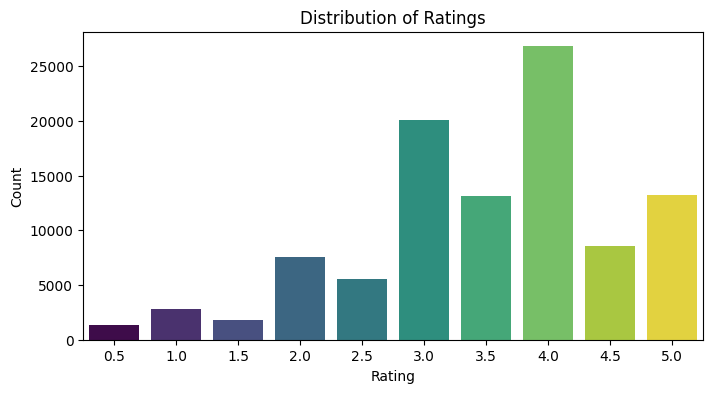

Missing values in movies:
 movieId    0
title      0
genres     0
dtype: int64

Missing values in links:
 movieId    0
imdbId     0
tmdbId     8
dtype: int64


In [3]:
# How are ratings spread out? (0.5 to 5.0 in 0.5 steps)
# This matters because a skewed distribution (e.g. mostly 3-5 stars)
# affects how we interpret RMSE/MAE later in evaluation.

plt.figure(figsize=(8, 4))

# hue=x + legend=False avoids the seaborn deprecation warning
sns.countplot(x='rating', data=ratings, hue='rating', palette='viridis', legend=False)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# Check for missing values in movies/links —
# some movies may have no tmdbId, which means no plot overview later.
print("Missing values in movies:\n", movies.isnull().sum())
print("\nMissing values in links:\n", links.isnull().sum())


## Step 1 — Train / Validation / Test Split (60% / 20% / 20%)

Matches the train/validation/test methodology used in COMP813 Assignment 1
(linear regression) and Assignment 2 (CNN classification): every
hyperparameter is tuned on a **validation** set, and the **test** set is
touched only once, at the very end, to report final numbers. The earlier
80/20 train/test split let SVD's `n_factors` get chosen by looking
directly at test performance — a leak this 3-way split removes.


In [4]:
# 3-way per-user split (60% train / 20% validation / 20% test), seeded with
# the student ID — same convention as Assignment 1's np.random.seed(STUDENT_ID).
ds = pipeline.split()  # defaults: val_frac=0.2, test_frac=0.2, seed=STUDENT_ID

print("Train matrix shape:    ", ds.train_matrix.shape)
print("Trainval matrix shape: ", ds.trainval_matrix.shape, "(train+val, for the final refit)")
print("Train rows:", len(ds.train_df), " Val rows:", len(ds.val_df), " Test rows:", len(ds.test_df))

# Sanity checks:
assert ds.train_matrix.shape == pipeline.user_item_matrix.shape, "Grid mismatch!"
assert len(ds.train_df) + len(ds.val_df) + len(ds.test_df) == len(pipeline.ratings), "Rows lost!"

train_pairs = set(zip(ds.train_df.userId, ds.train_df.movieId))
val_pairs = set(zip(ds.val_df.userId, ds.val_df.movieId))
test_pairs = set(zip(ds.test_df.userId, ds.test_df.movieId))
assert not (train_pairs & val_pairs), "train/val overlap!"
assert not (train_pairs & test_pairs), "train/test overlap!"
assert not (val_pairs & test_pairs), "val/test overlap!"

min_train = ds.train_df.groupby("userId").size().min()
print("Min train ratings per user:", min_train, "(must be >= 1)")
print("\nAll sanity checks passed \u2014 splits are disjoint, exhaustive, every user has train data.")


Train matrix shape:     (610, 9724)
Trainval matrix shape:  (610, 9724) (train+val, for the final refit)
Train rows: 60956  Val rows: 19940  Test rows: 19940
Min train ratings per user: 12 (must be >= 1)

All sanity checks passed — splits are disjoint, exhaustive, every user has train data.


## Step 2 — Hyperparameter Search: k × damping (selected on VALIDATION)

Mirrors Assignment 1's Task 1 grid search (learning rate × iterations,
selected by validation MSE): here the two SVD hyperparameters are
`n_factors` (k) and `damping` (how strongly an item's bias is shrunk
toward 0 when it has few ratings — `bias = residual_sum / (count + damping)`).
Both are fit on the 60% TRAIN matrix and scored on the 20% VALIDATION set;
TEST is not touched anywhere in this step.


In [5]:
from core.models.svd import SVDRecommender
from core.evaluation.metrics import evaluate, evaluate_model

# 1. Hyperparameter grid to explore
ks = [5, 10, 15, 20, 30, 50]
damps = [1, 5, 10, 25, 50]

val_rmse_matrix = np.zeros((len(ks), len(damps)))
best_rmse, best_k, best_damp, best_model = float("inf"), None, None, None

# 2. Grid search: fit on TRAIN, select on VALIDATION \u2014 same pattern as
#    Assignment 1's "train on TRAIN, select on VALIDATION" loop.
for i, k in enumerate(ks):
    for j, d in enumerate(damps):
        model = SVDRecommender(n_factors=k, damping=d).fit(ds.train_matrix)
        metrics, n_valid, n_total = evaluate_model(model, ds.val_df)
        val_rmse_matrix[i, j] = metrics["RMSE"]

        if metrics["RMSE"] < best_rmse:   # keep the best FITTED MODEL, not just the (k, damp) pair
            best_rmse, best_k, best_damp, best_model = metrics["RMSE"], k, d, model

print(f"Validation-selected hyperparameters: k={best_k}, damping={best_damp}  (val RMSE={best_rmse:.4f})")


Validation-selected hyperparameters: k=10, damping=5  (val RMSE=0.8789)


### Step 2's Graph — Validation RMSE Heatmap (k vs damping)

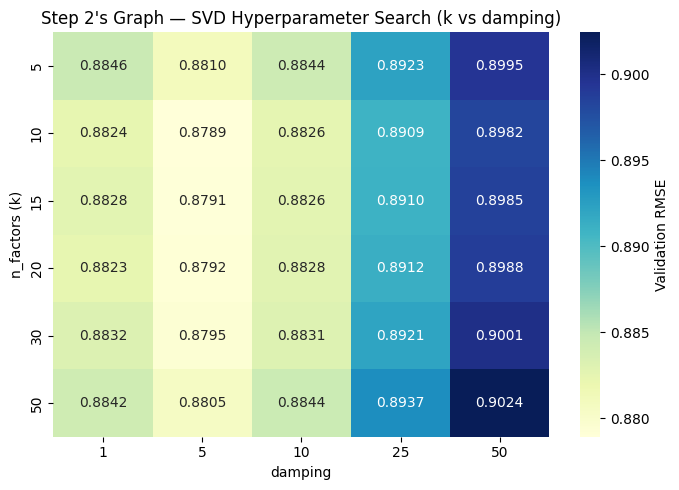

In [6]:
# Heatmap of validation RMSE across the full (k, damping) grid computed in
# Step 2 \u2014 same idea as Assignment 1's val-MSE heatmap, kept in its own
# cell so re-running the (slow) grid search doesn't require re-plotting,
# and vice versa.
plt.figure(figsize=(7, 5))
sns.heatmap(val_rmse_matrix, annot=True, fmt=".4f", cmap="YlGnBu",
            xticklabels=damps, yticklabels=ks,
            cbar_kws={"label": "Validation RMSE"})
plt.title("Step 2's Graph \u2014 SVD Hyperparameter Search (k vs damping)")
plt.xlabel("damping"); plt.ylabel("n_factors (k)")
plt.tight_layout(); plt.show()


## Step 3 — Final Evaluation (Validation + Test, touched ONCE)

Two results, matching Assignment 1's pattern:
1. The **same fitted model** selected in Step 2 (trained on the 60% TRAIN
   split) evaluated on both VALIDATION and TEST — directly comparable to
   Assignment 1's `val_best` / `test_best` table.
2. A **deployment model**, refit on TRAIN+VALIDATION (80%) with the same
   validated hyperparameters, evaluated on TEST — the model that would
   actually ship, since discarding the validation 20% at deployment time
   wastes data for no reason.

TEST is evaluated exactly once in the cell below, for every model in the
final comparison table — never again after this.


In [7]:
# --- 1. Assignment-1-style: the SAME model, evaluated on val AND test ---
val_metrics, _, _ = evaluate_model(best_model, ds.val_df)
test_metrics, _, _ = evaluate_model(best_model, ds.test_df)

a1_style_table = pd.DataFrame([
    {"Set": "Validation", **val_metrics},
    {"Set": "Test (touched once, here)", **test_metrics},
])
print("--- Model selected by validation, evaluated on val + test ---")
print(a1_style_table.to_string(index=False,
      formatters={"MSE": "{:.4f}".format, "RMSE": "{:.4f}".format, "MAE": "{:.4f}".format}))

# --- 2. Deployment model: refit on TRAIN+VAL (80%), same (k, damping) ---
deploy_model = SVDRecommender(n_factors=best_k, damping=best_damp).fit(ds.trainval_matrix)
deploy_result = evaluate_model(deploy_model, ds.test_df)
deploy_metrics = deploy_result.metrics
print(f"\n--- Deployment model (refit on train+val, 80%) ---")
# coverage() separates real predictions from the user-mean fallback on
# items with zero train ratings - the old n_valid/n_total hid that.
print(f"Test RMSE: {deploy_metrics['RMSE']:.4f}  MAE: {deploy_metrics['MAE']:.4f}")
print(f"Coverage: {deploy_result.coverage()}")

# --- 3. Baseline: user-mean, from the SAME 80% data the deployment model saw ---
user_means = ds.trainval_matrix.mean(axis=1)
baseline_pred = ds.test_df["userId"].map(user_means)
baseline_metrics = evaluate(ds.test_df["rating"], baseline_pred)
print(f"\n--- User-mean baseline (test) ---")
print(f"RMSE: {baseline_metrics['RMSE']:.4f}  MAE: {baseline_metrics['MAE']:.4f}")

# --- 4. External library check: does our custom SVD (with item-bias) beat
#    an off-the-shelf implementation with no item-bias term? Mirrors
#    Assignment 1's "compare against sklearn LinearRegression" step. ---
from sklearn.decomposition import TruncatedSVD

mat = ds.trainval_matrix
means = mat.mean(axis=1)
filled = mat.sub(means, axis=0).fillna(0.0).to_numpy()

sk_svd = TruncatedSVD(n_components=best_k, random_state=STUDENT_ID)
u = sk_svd.fit_transform(filled)
recon = np.clip(u @ sk_svd.components_ + means.to_numpy().reshape(-1, 1), 0.5, 5.0)
recon_df = pd.DataFrame(recon, index=mat.index, columns=mat.columns)

sk_pred = ds.test_df.apply(
    lambda r: recon_df.loc[r["userId"], r["movieId"]] if r["movieId"] in recon_df.columns else np.nan,
    axis=1,
)
sk_valid = sk_pred.notna()
sk_metrics = evaluate(ds.test_df.loc[sk_valid, "rating"], sk_pred[sk_valid])
print(f"\n--- sklearn TruncatedSVD baseline (no item-bias, k={best_k}) ---")
print(f"RMSE: {sk_metrics['RMSE']:.4f}  MAE: {sk_metrics['MAE']:.4f}")

# --- Summary ---
summary = pd.DataFrame([
    {"Model": "User-mean baseline", **baseline_metrics},
    {"Model": f"sklearn TruncatedSVD (k={best_k})", **sk_metrics},
    {"Model": f"Custom SVD, val-selected (k={best_k}, damp={best_damp}) \u2014 train only", **test_metrics},
    {"Model": f"Custom SVD, deployment (k={best_k}, damp={best_damp}) \u2014 train+val", **deploy_metrics},
])
print("\n=== Final test-set comparison (test touched once, in this cell, for every model above) ===")
print(summary.to_string(index=False,
      formatters={"MSE": "{:.4f}".format, "RMSE": "{:.4f}".format, "MAE": "{:.4f}".format}))


--- Model selected by validation, evaluated on val + test ---
                      Set    MSE   RMSE    MAE
               Validation 0.7725 0.8789 0.6727
Test (touched once, here) 0.7781 0.8821 0.6745

--- Deployment model (refit on train+val, 80%) ---
Test RMSE: 0.8734  MAE: 0.6663
Coverage: 19940/19940 rows predicted; 19146 backed by real evidence, 794 fell back to the user-mean baseline

--- User-mean baseline (test) ---
RMSE: 0.9448  MAE: 0.7353

--- sklearn TruncatedSVD baseline (no item-bias, k=10) ---
RMSE: 0.9153  MAE: 0.7063

=== Final test-set comparison (test touched once, in this cell, for every model above) ===
                                               Model    MSE   RMSE    MAE
                                  User-mean baseline 0.8927 0.9448 0.7353
                         sklearn TruncatedSVD (k=10) 0.8378 0.9153 0.7063
Custom SVD, val-selected (k=10, damp=5) — train only 0.7781 0.8821 0.6745
   Custom SVD, deployment (k=10, damp=5) — train+val 0.7628 0.8734 0.6

### Step 3's Graph — Final Test RMSE Comparison

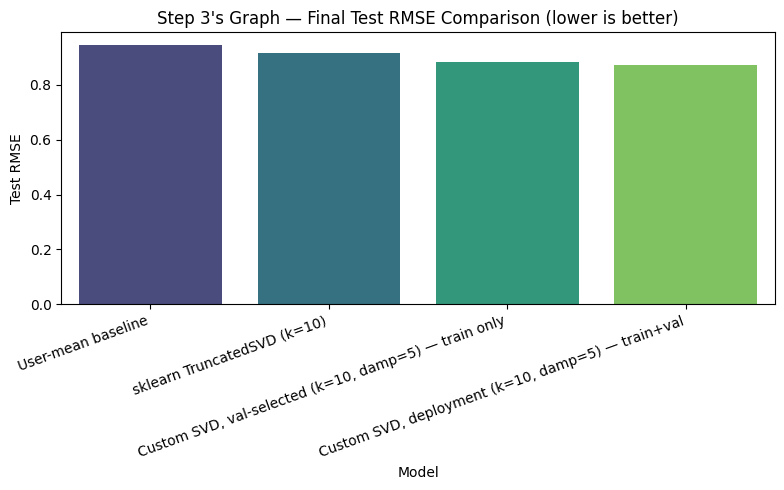

In [8]:
# Bar chart of the `summary` table built in Step 3 \u2014 same "final
# comparison bar chart" pattern as Assignment 1's Task 2 / Task 4.
plt.figure(figsize=(8, 5))
sns.barplot(data=summary, x="Model", y="RMSE", hue="Model", palette="viridis", legend=False)
plt.title("Step 3's Graph \u2014 Final Test RMSE Comparison (lower is better)")
plt.ylabel("Test RMSE")
plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()


## Step 4 — Ranking Quality: Precision@K / Recall@K / NDCG@K

RMSE measures how close a predicted *number* is to the true rating — it says
nothing about whether the *right movies* end up near the top of a user's
recommendation list, which is what a recommender is actually judged on in
practice. This step re-selects the SVD centering variant on a ranking
metric instead of RMSE, at the (k, damping) already validated in Step 2,
following the same "select on VALIDATION, touch TEST once" discipline as
Steps 2 and 3. The RMSE-best model is not automatically the ranking-best
model: `center="user+item"` wins on RMSE but its item-bias term was shown
earlier to flatten/dominate the top of the ranked list, which hurts NDCG.

In [9]:
from core.evaluation.ranking import (
    build_relevant_items,
    evaluate_ranking,        # single cutoff — used for the centering selection below
    evaluate_ranking_at_ks,  # several cutoffs in ONE pass over the users
)

# 1. Re-select the SVD centering variant for RANKING (not RMSE) on VALIDATION,
#    at the (k, damping) already chosen in Step 2.
relevant_val = build_relevant_items(ds.val_df, threshold=4.0)

ranking_candidates = {}
for center in ["user", "user+item"]:
    m = SVDRecommender(n_factors=best_k, damping=best_damp, center=center).fit(ds.train_matrix)
    recommend_fn = lambda uid, m=m: m.recommend_top_n(uid, n=10, exclude_seen=True).index.tolist()
    ranking_candidates[center] = evaluate_ranking(recommend_fn, relevant_val, k=10)

for center, res in ranking_candidates.items():
    print(f"center={center!r:14s}  NDCG@10={res['NDCG@10']:.4f}  "
          f"Precision@10={res['Precision@10']:.4f}  Recall@10={res['Recall@10']:.4f}  "
          f"(n_users={res['n_users']})")

best_center = max(ranking_candidates, key=lambda c: ranking_candidates[c]["NDCG@10"])
print(f"\nValidation-selected centering for RANKING: center={best_center!r}")

# 2. Refit the ranking-selected variant on TRAIN+VAL (80%) — same "refit once
#    tuning is done" pattern as the deployment model in Step 3.
rank_model = SVDRecommender(n_factors=best_k, damping=best_damp, center=best_center).fit(ds.trainval_matrix)

# 3. Multi-K Precision/Recall/NDCG on TEST, touched once here for ranking.
#    exclude_seen uses rank_model's own _seen_mask, captured from
#    trainval_matrix at fit time, so recommendations correctly skip
#    anything the user rated in TRAIN or VAL.
relevant_test = build_relevant_items(ds.test_df, threshold=4.0)
Ks = [5, 10, 20]
recommend_fn_test = lambda uid: rank_model.recommend_top_n(uid, n=max(Ks), exclude_seen=True).index.tolist()

# evaluate_ranking() inside a `for k in Ks` loop rebuilt every user's ranked
# list once per k — 1,806 recommendation builds for 602 users across 3 Ks.
# The list doesn't depend on k, only the cutoff does, so build it once and
# slice it. Identical numbers, ~3x less work.
ranking_by_k = evaluate_ranking_at_ks(recommend_fn_test, relevant_test, Ks)
ranking_results = pd.DataFrame([
    {
        "K": k,
        "Precision": res[f"Precision@{k}"],
        "Recall": res[f"Recall@{k}"],
        "NDCG": res[f"NDCG@{k}"],
        "n_users": res["n_users"],
    }
    for k, res in ranking_by_k.items()
]).set_index("K")

print(f"\n=== Final ranking metrics on TEST (center={best_center!r}, k={best_k}, damping={best_damp}) ===")
print(ranking_results.to_string(formatters={
    c: "{:.4f}".format for c in ["Precision", "Recall", "NDCG"]
}))

center='user'          NDCG@10=0.1060  Precision@10=0.0885  Recall@10=0.0725  (n_users=598)
center='user+item'     NDCG@10=0.0398  Precision@10=0.0360  Recall@10=0.0240  (n_users=598)

Validation-selected centering for RANKING: center='user'

=== Final ranking metrics on TEST (center='user', k=10, damping=5) ===
   Precision Recall   NDCG  n_users
K                                  
5     0.1415 0.0549 0.1596      602
10    0.1164 0.0911 0.1502      602
20    0.0870 0.1328 0.1456      602


### Step 4's Graph — Centering Selection & Ranking Metrics vs K

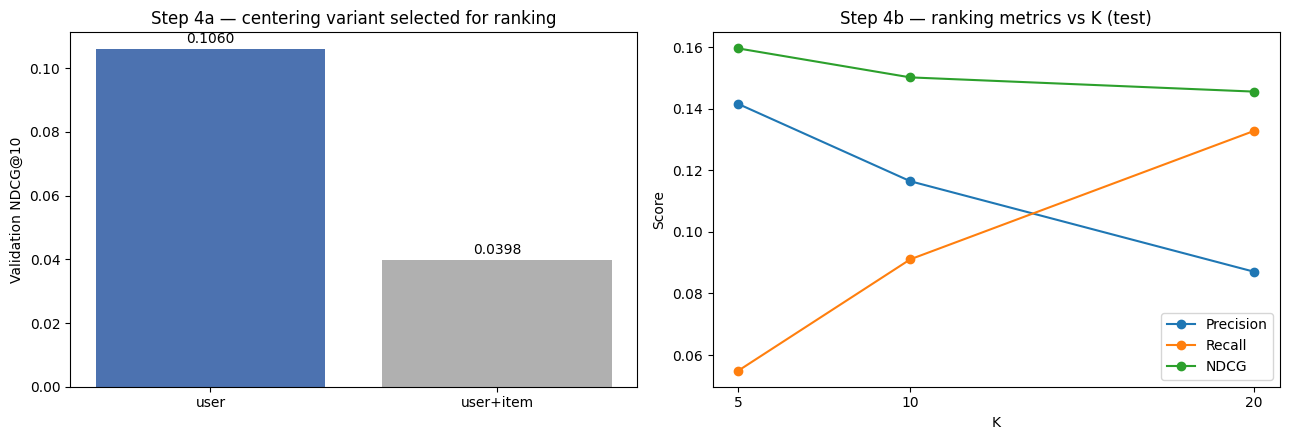

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: validation NDCG@10 by centering variant — shows why best_center was picked
centers = list(ranking_candidates.keys())
ndcgs = [ranking_candidates[c]["NDCG@10"] for c in centers]
colors = ["#4C72B0" if c == best_center else "#B0B0B0" for c in centers]
axes[0].bar(centers, ndcgs, color=colors)
axes[0].set_ylabel("Validation NDCG@10")
axes[0].set_title("Step 4a — centering variant selected for ranking")
for i, v in enumerate(ndcgs):
    axes[0].text(i, v + 0.002, f"{v:.4f}", ha="center")

# Right: Precision/Recall/NDCG vs K on test, for the ranking-selected model
for metric in ["Precision", "Recall", "NDCG"]:
    axes[1].plot(ranking_results.index, ranking_results[metric], marker="o", label=metric)
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score")
axes[1].set_xticks(Ks)
axes[1].set_title("Step 4b — ranking metrics vs K (test)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 5 — Content-Based Model (TF-IDF on plot overviews)

Steps 2-4 are pure Collaborative Filtering: every prediction comes from *other
users' ratings*, so an item nobody has rated yet cannot be ranked at all. This
step adds the NLP half of the project — a TF-IDF + cosine-similarity model over
TMDB plot overviews, which needs no ratings for the item it is scoring.

Two things differ from Steps 2-4 and both are deliberate:

1. **Ranking metrics only, no RMSE.** This model outputs cosine similarity
   (roughly 0-1), not a star rating, so RMSE against a 0.5-5.0 rating column is
   a category error — it produced a meaningless "RMSE 3.71" before
   `evaluate_model()` was taught to refuse it (`produces_ratings = False`).
2. **Coverage is reported first.** The model can only speak for movies that have
   plot text, and that is a minority of the catalogue. Quoting its ranking
   scores without that caveat would overstate what it contributes.

Same discipline as before: `use_genres` is selected on VALIDATION, the winner is
refit on TRAIN+VAL, and TEST is touched once.

In [11]:
from core.models.content import ContentBasedRecommender

# --- 1. Coverage: what fraction of the catalogue can this model even score? ---
# Reported BEFORE the metrics on purpose. A content model that looks mediocre
# overall may simply have no text for most items, which is a data-collection
# problem, not a modelling one — the report needs to separate the two.
text_ids = set(text_corpus["movieId"]) & set(ds.train_matrix.columns)
n_items = ds.train_matrix.shape[1]
print(f"Movies with plot text: {len(text_ids)}/{n_items} "
      f"({100 * len(text_ids) / n_items:.1f}% of the rated catalogue)")

train_counts = ds.train_matrix.notna().sum(axis=0)
cold_ids = set(train_counts[train_counts == 0].index)
print(f"Items with 0 train ratings: {len(cold_ids)}; of those, {len(cold_ids & text_ids)} have text "
      f"({100 * len(cold_ids & text_ids) / len(cold_ids):.1f}% of the cold-start cases "
      f"this model can currently reach)")

# --- 2. Select use_genres on VALIDATION ranking (its only hyperparameter) ---
# Genre tokens are appended to the plot text when True. Same select-on-validation
# pattern as Step 2's (k, damping) grid and Step 4's centering choice.
content_candidates = {}
for use_genres in [False, True]:
    cm = ContentBasedRecommender(use_genres=use_genres).fit(ds.train_matrix, text_corpus)
    # recommend_top_n() now excludes the user's train-rated movies by default,
    # using the mask captured in fit(). It previously required the caller to
    # pass seen_movie_ids and silently excluded NOTHING when they didn't —
    # which filled the top-10 with movies the user had already rated.
    fn = lambda uid, cm=cm: cm.recommend_top_n(uid, n=10).index.tolist()
    res = evaluate_ranking(fn, relevant_val, k=10)
    content_candidates[use_genres] = res
    print(f"use_genres={str(use_genres):<5}  NDCG@10={res['NDCG@10']:.4f}  "
          f"Precision@10={res['Precision@10']:.4f}  Recall@10={res['Recall@10']:.4f}  "
          f"(n_users={res['n_users']}, no recommendations for {res['n_no_recs']})")

best_use_genres = max(content_candidates, key=lambda g: content_candidates[g]["NDCG@10"])
print(f"\nValidation-selected: use_genres={best_use_genres}")

# --- 3. Refit on TRAIN+VAL (80%), evaluate on TEST once, at Step 4's Ks ---
content_model = ContentBasedRecommender(use_genres=best_use_genres).fit(
    ds.trainval_matrix, text_corpus
)
recommend_fn_content = lambda uid: content_model.recommend_top_n(uid, n=max(Ks)).index.tolist()

content_by_k = evaluate_ranking_at_ks(recommend_fn_content, relevant_test, Ks)
content_results = pd.DataFrame([
    {
        "K": k,
        "Precision": res[f"Precision@{k}"],
        "Recall": res[f"Recall@{k}"],
        "NDCG": res[f"NDCG@{k}"],
        "n_users": res["n_users"],
    }
    for k, res in content_by_k.items()
]).set_index("K")

print(f"\n=== Content-based model on TEST (use_genres={best_use_genres}) ===")
print(content_results.to_string(formatters={
    c: "{:.4f}".format for c in ["Precision", "Recall", "NDCG"]
}))

# --- 4. Sanity check that the seen-exclusion fix is actually in effect ---
# Guards the exact bug described above: if this ever prints a non-zero number,
# the model is "recommending" movies the user already rated and every ranking
# score in this step is inflated and meaningless.
leaked = 0
for uid in list(ds.trainval_matrix.index)[:50]:
    already_rated = set(ds.train_df.loc[ds.train_df.userId == uid, "movieId"]) | \
                    set(ds.val_df.loc[ds.val_df.userId == uid, "movieId"])
    leaked += len(set(recommend_fn_content(uid)) & already_rated)
print(f"\nSanity check — already-rated movies in the first 50 users' recommendations: {leaked} (must be 0)")

# --- 5. Side by side with Step 4's SVD, which is the point of the comparison ---
comparison = ranking_results[["Precision", "Recall", "NDCG"]].join(
    content_results[["Precision", "Recall", "NDCG"]], lsuffix=" (SVD)", rsuffix=" (Content)"
)
print("\n=== SVD vs Content-based on TEST ===")
print(comparison.to_string(formatters={c: "{:.4f}".format for c in comparison.columns}))

Movies with plot text: 9603/9724 (98.8% of the rated catalogue)
Items with 0 train ratings: 1641; of those, 1609 have text (98.0% of the cold-start cases this model can currently reach)
use_genres=False  NDCG@10=0.0303  Precision@10=0.0206  Recall@10=0.0202  (n_users=597, no recommendations for 1)
use_genres=True   NDCG@10=0.0293  Precision@10=0.0206  Recall@10=0.0205  (n_users=597, no recommendations for 1)

Validation-selected: use_genres=False

=== Content-based model on TEST (use_genres=False) ===
   Precision Recall   NDCG  n_users
K                                  
5     0.0313 0.0218 0.0401      601
10    0.0215 0.0275 0.0359      601
20    0.0141 0.0317 0.0345      601

Sanity check — already-rated movies in the first 50 users' recommendations: 0 (must be 0)

=== SVD vs Content-based on TEST ===
   Precision (SVD) Recall (SVD) NDCG (SVD) Precision (Content) Recall (Content) NDCG (Content)
K                                                                                        

### Step 5's Graph — Content vs SVD, and why a hybrid is the next step

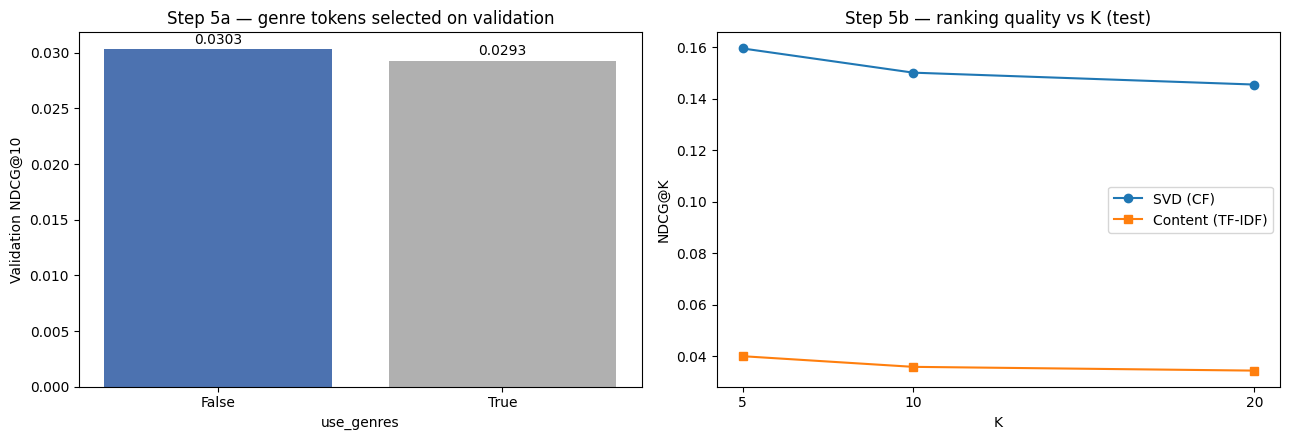

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: validation NDCG@10 by use_genres — shows why best_use_genres was picked.
opts = [str(g) for g in content_candidates]
vals = [content_candidates[g]["NDCG@10"] for g in content_candidates]
cols = ["#4C72B0" if g == best_use_genres else "#B0B0B0" for g in content_candidates]
axes[0].bar(opts, vals, color=cols)
axes[0].set_xlabel("use_genres")
axes[0].set_ylabel("Validation NDCG@10")
axes[0].set_title("Step 5a — genre tokens selected on validation")
for i, v in enumerate(vals):
    axes[0].text(i, v + 0.0005, f"{v:.4f}", ha="center")

# Right: NDCG@K on test, both models on one axis. The gap is the argument for
# the hybrid: content is much weaker alone, but it is the only one of the two
# that can score an item with no ratings at all.
axes[1].plot(ranking_results.index, ranking_results["NDCG"], marker="o", label="SVD (CF)")
axes[1].plot(content_results.index, content_results["NDCG"], marker="s", label="Content (TF-IDF)")
axes[1].set_xlabel("K"); axes[1].set_ylabel("NDCG@K")
axes[1].set_xticks(Ks)
axes[1].set_title("Step 5b — ranking quality vs K (test)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 6 — Responsible AI: Popularity Bias & Cold-Start Fairness

Ranking quality (Step 4/5) asks "are the recommendations good". This step
asks a different question: "good for whom, and at whose expense". Two
checks, both cheap to compute from data already built:

1. **Popularity bias** — does a "personalized" model actually personalize,
   or does it mostly reshuffle the same best-sellers for everyone? Measured
   against a naive Most-Popular baseline (no personalization at all) as the
   reference point: catalogue coverage (how much of the 9,724-movie catalogue
   ever gets recommended to anyone) and the mean popularity of recommended
   items vs the catalogue average.
2. **Cold-start fairness** — demonstrated in Step 6b below: Step 3
   showed SVD's RMSE on items with zero train ratings collapses exactly to
   the user-mean baseline (no real signal at all), and Step 5 showed the
   content model only has plot text for 18% of those same items. Together
   this means a user whose taste skews toward niche, rarely-rated movies is
   systematically underserved by EITHER model alone — not a ranking-quality
   gap, a coverage gap. This is the strongest argument for the hybrid: it
   isn't just "better NDCG", it's "serves the users the other two don't".

In [13]:
# Item popularity: how many TRAIN+VAL ratings each item received — the raw
# signal a collaborative model implicitly leans on (more raters -> more
# reliable signal -> easier to get right, which is exactly the bias risk).
popularity = ds.trainval_matrix.notna().sum(axis=0)  # Series indexed by movieId
catalog_avg_popularity = popularity.mean()
# kind="mergesort" is STABLE, matching SVDRecommender.recommend_top_n(). The
# default quicksort is not, and popularity counts are almost all ties:
# 9,682 of 9,724 items share their count with another item, and 79 of the
# top 120 sit in a tied group, so an unstable sort silently reshuffles the
# baseline's top-N between runs and its NDCG drifts in the 4th decimal.
# Stable sorting makes ties resolve to ascending movieId, deterministically.
popularity_ranked = popularity.sort_values(ascending=False, kind="mergesort")

# Naive "most popular" recommender: zero personalization, same best-sellers
# for everyone minus what they've already rated. The reference point — if
# SVD/content aren't meaningfully less concentrated than THIS, personalization
# isn't buying much diversity, whatever the ranking metrics say.
# islice stops as soon as n items are found. The list-comprehension version
# filtered all 9,724 items for every user before slicing 10 off the front —
# ~5.9M membership tests across 610 users to produce 6,100 recommendations.
from itertools import islice

seen_by_user = {
    uid: set(ds.trainval_matrix.columns[ds.trainval_matrix.loc[uid].notna()])
    for uid in ds.trainval_matrix.index
}

def recommend_popular(user_id, n=10):
    if user_id not in ds.trainval_matrix.index:
        return []
    seen = seen_by_user[user_id]
    return list(islice((m for m in popularity_ranked.index if m not in seen), n))

recommenders = {
    "SVD (personalized)": lambda uid: rank_model.recommend_top_n(uid, n=10, exclude_seen=True).index.tolist(),
    "Content (personalized)": lambda uid: content_model.recommend_top_n(uid, n=10).index.tolist(),
    "Most-Popular (naive)": recommend_popular,
}

# What each recommender could rank even in principle. SVD and Most-Popular see
# the whole rated catalogue; the content model only sees movies with plot text.
n_text_items = len(set(text_corpus["movieId"]) & set(ds.trainval_matrix.columns))
reachable_pool = {
    "SVD (personalized)": len(popularity),
    "Content (personalized)": n_text_items,
    "Most-Popular (naive)": len(popularity),
}

all_users = ds.trainval_matrix.index
bias_rows = []
for name, fn in recommenders.items():
    recommended_items = set()
    pop_values = []
    for uid in all_users:
        for m in fn(uid):
            recommended_items.add(m)
            pop_values.append(popularity.get(m, 0))
    bias_rows.append({
        "Recommender": name,
        "Catalog coverage": len(recommended_items) / len(popularity),
        # Coverage against the full catalogue is unfair to the content model:
        # it can only ever rank the ~36% of movies that HAVE plot text, so its
        # catalogue-wide number understates how much of its own reachable space
        # it uses. Dividing by each model's reachable pool makes the diversity
        # comparison apples-to-apples.
        "Coverage of reachable pool": len(recommended_items) / reachable_pool[name],
        "Mean popularity of recs": float(np.mean(pop_values)) if pop_values else np.nan,
    })

bias_df = pd.DataFrame(bias_rows).set_index("Recommender")
print(f"Catalogue-average item popularity: {catalog_avg_popularity:.1f} ratings/item")
print(bias_df.to_string(formatters={
    "Catalog coverage": "{:.1%}".format,
    "Coverage of reachable pool": "{:.1%}".format,
    "Mean popularity of recs": "{:.1f}".format,
}))

Catalogue-average item popularity: 8.3 ratings/item
                       Catalog coverage Coverage of reachable pool Mean popularity of recs
Recommender                                                                               
SVD (personalized)                 4.0%                       4.0%                   138.9
Content (personalized)            24.9%                      25.3%                    14.5
Most-Popular (naive)               0.6%                       0.6%                   196.9


### Step 6b — Does personalization actually beat "recommend the best-sellers"?

The Most-Popular recommender above is not just a bias reference point — it is
the standard sanity baseline in recommender-systems evaluation, and it has to
be scored on the SAME ranking metrics as the real models. A personalized model
that cannot beat a non-personalized one is not yet earning its complexity, and
that is a result worth reporting honestly rather than leaving unmeasured.

This cell also supplies the evidence for the cold-start claim made above, which
until now was asserted rather than demonstrated: on test ratings for items with
zero train+val ratings, SVD's prediction is not merely *close to* the user-mean
baseline, it is **identical to it**, because the factor model reconstructs
nothing for a column it never saw.

In [14]:
# --- 1. Score Most-Popular on the same ranking metrics as SVD and Content ---
baseline_rankers = {
    "SVD (personalized)": lambda uid: rank_model.recommend_top_n(uid, n=max(Ks), exclude_seen=True).index.tolist(),
    "Content (personalized)": lambda uid: content_model.recommend_top_n(uid, n=max(Ks)).index.tolist(),
    "Most-Popular (naive)": lambda uid: recommend_popular(uid, n=max(Ks)),
}

bias_ranking = {
    name: evaluate_ranking_at_ks(fn, relevant_test, Ks)
    for name, fn in baseline_rankers.items()
}

ndcg_table = pd.DataFrame(
    {name: {k: res[k][f"NDCG@{k}"] for k in Ks} for name, res in bias_ranking.items()}
)
ndcg_table.index.name = "K"
precision_table = pd.DataFrame(
    {name: {k: res[k][f"Precision@{k}"] for k in Ks} for name, res in bias_ranking.items()}
)
precision_table.index.name = "K"

print("=== NDCG@K on TEST — personalized models vs the naive baseline ===")
print(ndcg_table.to_string(float_format=lambda v: f"{v:.4f}"))
print("\n=== Precision@K on TEST ===")
print(precision_table.to_string(float_format=lambda v: f"{v:.4f}"))

svd_wins = int((ndcg_table["SVD (personalized)"] > ndcg_table["Most-Popular (naive)"]).sum())
print(f"\nSVD beats Most-Popular on NDCG at {svd_wins} of {len(Ks)} cutoffs.")
print("Note: SVD DOES clearly win on rating error (Step 3: test RMSE "
      f"{deploy_metrics['RMSE']:.4f} vs {baseline_metrics['RMSE']:.4f} for the user-mean baseline).")
print("Winning at rating prediction while not winning at ranking is the whole")
print("reason Step 4 separates the two metric families — and the motivation for")
print("the hybrid: a model that cannot out-rank best-sellers needs a second signal.")

# --- 2. Evidence for the cold-start claim: SVD == user-mean on unseen items ---
cold_items = popularity[popularity == 0].index
cold_rows = ds.test_df[ds.test_df["movieId"].isin(cold_items)]
trainval_user_means = ds.trainval_matrix.mean(axis=1)

cold_svd = cold_rows.apply(
    lambda r: deploy_model.predict(r["userId"], r["movieId"]), axis=1
).astype(float)
cold_mean = cold_rows["userId"].map(trainval_user_means).astype(float)

print(f"\n=== Cold-start evidence ===")
print(f"Items with 0 train+val ratings: {len(cold_items)}; test ratings on them: {len(cold_rows)}")
print(f"Max |SVD prediction - user mean| on those rows: {np.abs(cold_svd - cold_mean).max():.2e}")
print(f"SVD RMSE on cold rows:       {evaluate(cold_rows['rating'], cold_svd)['RMSE']:.4f}")
print(f"User-mean RMSE on cold rows: {evaluate(cold_rows['rating'], cold_mean)['RMSE']:.4f}")
print("Identical, as expected: for a column with no ratings the reconstruction")
print("contributes nothing, so the 'prediction' is the user's own average.")

=== NDCG@K on TEST — personalized models vs the naive baseline ===
    SVD (personalized)  Content (personalized)  Most-Popular (naive)
K                                                                   
5               0.1596                  0.0401                0.1641
10              0.1502                  0.0359                0.1549
20              0.1456                  0.0345                0.1562

=== Precision@K on TEST ===
    SVD (personalized)  Content (personalized)  Most-Popular (naive)
K                                                                   
5               0.1415                  0.0313                0.1429
10              0.1164                  0.0215                0.1153
20              0.0870                  0.0141                0.0885

SVD beats Most-Popular on NDCG at 0 of 3 cutoffs.
Note: SVD DOES clearly win on rating error (Step 3: test RMSE 0.8734 vs 0.9448 for the user-mean baseline).
Winning at rating prediction while not winning at ranki

### Step 6's Graph — Coverage and Popularity Bias vs the Naive Baseline

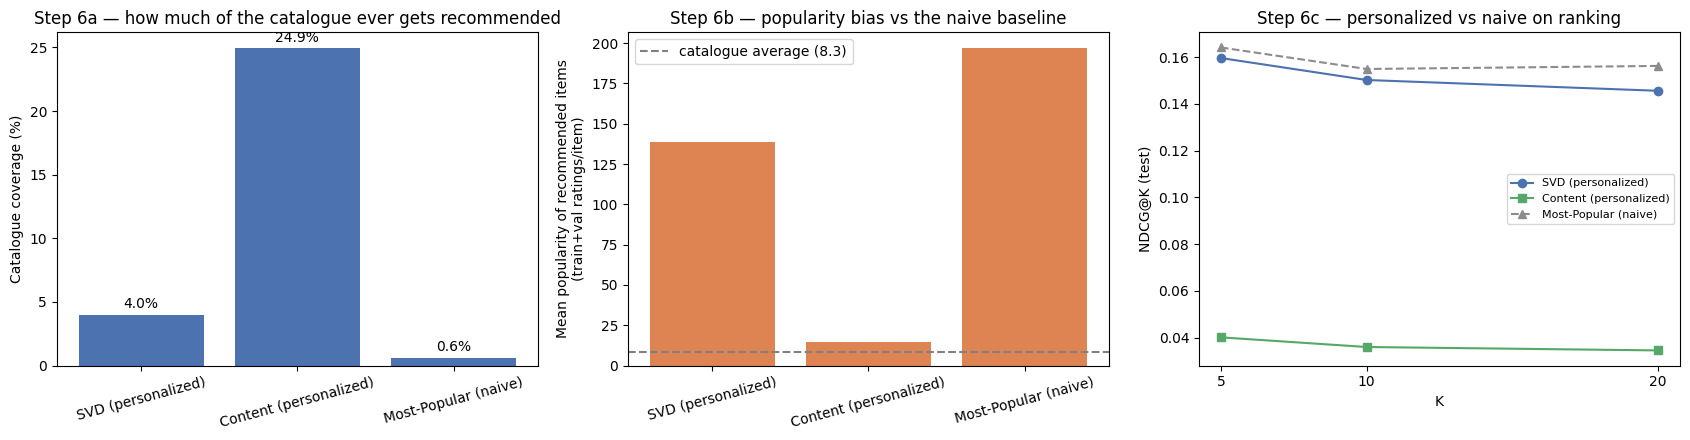

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].bar(bias_df.index, bias_df["Catalog coverage"] * 100, color="#4C72B0")
axes[0].set_ylabel("Catalogue coverage (%)")
axes[0].set_title("Step 6a — how much of the catalogue ever gets recommended")
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(bias_df["Catalog coverage"] * 100):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center")

axes[1].bar(bias_df.index, bias_df["Mean popularity of recs"], color="#DD8452")
axes[1].axhline(catalog_avg_popularity, color="gray", linestyle="--",
                 label=f"catalogue average ({catalog_avg_popularity:.1f})")
axes[1].set_ylabel("Mean popularity of recommended items\n(train+val ratings/item)")
axes[1].set_title("Step 6b — popularity bias vs the naive baseline")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend()

# Third panel is the one that matters most for the report: if the grey naive
# baseline sits at or above the personalized models, personalization is not
# paying for itself yet on ranking.
styles = {"SVD (personalized)": ("#4C72B0", "o", "-"),
          "Content (personalized)": ("#55A868", "s", "-"),
          "Most-Popular (naive)": ("#8C8C8C", "^", "--")}
for name in ndcg_table.columns:
    color, marker, ls = styles[name]
    axes[2].plot(ndcg_table.index, ndcg_table[name], marker=marker, linestyle=ls,
                 color=color, label=name)
axes[2].set_xlabel("K"); axes[2].set_ylabel("NDCG@K (test)")
axes[2].set_xticks(Ks)
axes[2].set_title("Step 6c — personalized vs naive on ranking")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Step 7 — Hybrid Model: Combining SVD and Content via Per-User Z-Scores

SVD and Content are on incompatible scales (predicted rating ~0.5-5 vs
cosine similarity ~0-1), so they can't be added directly. Each user's
candidate scores are z-scored (mean 0, std 1) first, then blended:
`score = alpha*svd_z + (1-alpha)*content_z`.

The one design decision everything else depends on: what happens to an
item the content model has NO plot text for (64% of the catalogue)? Giving
it the SVD score at FULL weight looks natural but is a real bias — a
text-less item's `content_z` is simply undefined, not 0, so handing it
`svd_z` alone (instead of `alpha*svd_z`) systematically favours text-less
items over ones the content model actually had an opinion on. This is
tested below as an explicit ablation (`fallback="neutral"` vs
`fallback="renormalise"`), not assumed.

alpha is tuned on VALIDATION, same pattern as every hyperparameter so far
(Step 2's k/damping, Step 4's centering, Step 5's use_genres) — the model
is refit on TRAIN only for this search so the already-selected
`rank_model`/`content_model` (fit on train+val) stay untouched until the
final comparison in Step 8.

In [16]:
from core.models.hybrid import HybridRecommender

# Retune on TRAIN only (60%), select on VALIDATION - the trainval-fit
# rank_model/content_model from Steps 4/5 are the DEPLOYMENT models and
# must not be touched until alpha is chosen.
svd_t = SVDRecommender(n_factors=best_k, damping=best_damp, center=best_center).fit(ds.train_matrix)
content_t = ContentBasedRecommender(use_genres=best_use_genres).fit(ds.train_matrix, text_corpus)

alphas = np.round(np.arange(0.0, 1.01, 0.1), 2)
alpha_results = {"neutral": {}, "renormalise": {}}

for fallback in ("neutral", "renormalise"):
    # ONE instance per fallback, reused across every alpha. svd_z and
    # content_z don't depend on alpha, so cache_components=True computes
    # them once per user instead of once per (alpha, user); only .alpha
    # changes between sweeps. Building a fresh HybridRecommender per alpha
    # threw that work away 11 times over.
    h = HybridRecommender(svd_t, content_t, fallback=fallback, cache_components=True)
    for a in alphas:
        h.alpha = a
        # h=h freezes THIS h in the lambda's default args - without it the
        # lambda would look up whatever h is bound to when it finally runs
        # (the closure-over-loop-variable bug).
        fn = lambda uid, h=h: h.recommend_top_n(uid, n=10, exclude_seen=True).index.tolist()
        alpha_results[fallback][a] = evaluate_ranking(fn, relevant_val, k=10)["NDCG@10"]

alpha_table = pd.DataFrame(alpha_results)
alpha_table.index.name = "alpha"
print("=== Validation NDCG@10 vs alpha, by fallback strategy (ablation) ===")
print(alpha_table.to_string(float_format=lambda v: f"{v:.4f}"))

best_fallback, best_alpha = max(
    ((fb, a) for fb in alpha_results for a in alpha_results[fb]),
    key=lambda pair: alpha_results[pair[0]][pair[1]],
)
print(f"\nValidation-selected: fallback={best_fallback!r}, alpha={best_alpha}  "
      f"(NDCG@10={alpha_results[best_fallback][best_alpha]:.4f})")

=== Validation NDCG@10 vs alpha, by fallback strategy (ablation) ===
       neutral  renormalise
alpha                      
0.0     0.0303       0.0303
0.1     0.0418       0.0417
0.2     0.0736       0.0735
0.3     0.1055       0.1054
0.4     0.1166       0.1164
0.5     0.1169       0.1168
0.6     0.1126       0.1126
0.7     0.1108       0.1108
0.8     0.1091       0.1091
0.9     0.1068       0.1068
1.0     0.1060       0.1060

Validation-selected: fallback='neutral', alpha=0.5  (NDCG@10=0.1169)


### Step 7's Graph — Validation NDCG@10 vs alpha, by fallback strategy

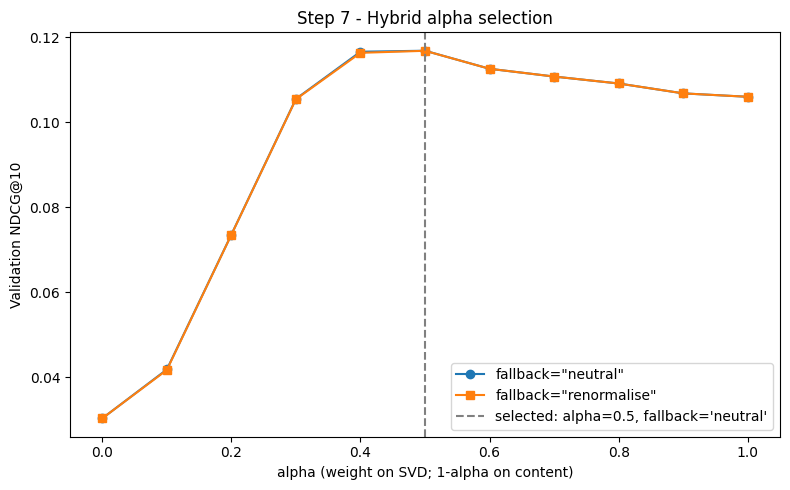

In [17]:
plt.figure(figsize=(8, 5))
for fallback, marker in (("neutral", "o"), ("renormalise", "s")):
    plt.plot(alpha_table.index, alpha_table[fallback], marker=marker, label=f'fallback="{fallback}"')
plt.axvline(best_alpha, color="gray", linestyle="--",
            label=f"selected: alpha={best_alpha}, fallback={best_fallback!r}")
plt.xlabel("alpha (weight on SVD; 1-alpha on content)")
plt.ylabel("Validation NDCG@10")
plt.title("Step 7 - Hybrid alpha selection")
plt.legend()
plt.tight_layout()
plt.show()

## Step 8 — Final Comparison: SVD vs Content vs Hybrid vs Most-Popular

Two hybrids are carried into the final comparison, both built from the
SAME already-fit `rank_model`/`content_model` (Steps 4/5, fit on
train+val) - no refitting needed, the hybrid only composes them:

- **Hybrid (weighted)** - the alpha-blend selected in Step 7.
- **Hybrid (switching)** - a second ablation: per item, trust whichever
  model has REAL evidence instead of blending everywhere - SVD's own
  signal for any item with >=1 train rating, content similarity for a
  train-cold item that has plot text, nothing for an item neither model
  can speak to. This targets cold-start directly and sidesteps the
  weighted blend's text-less-item bias entirely.

Ranking quality (NDCG/Precision@K) and coverage are measured exactly as in
Steps 4/5/6. The question that actually motivated this whole model - does
the hybrid reach cold-start items SVD alone cannot - gets a direct,
countable answer at the end of this step, not just an inference from NDCG.

Read that count carefully rather than as a headline: it is reported as a
share of all recommended slots, because "more than zero" and "materially
more" are different claims. If the count is small, then whatever ranking
gain the hybrid shows is coming from content RE-RANKING items the CF model
already covers, not from cold-start reach - and the report should say so.

In [18]:
# rank_model and content_model are ALREADY fit on trainval_matrix at their
# own validation-selected hyperparameters (Steps 4/5) - the hybrid just
# composes them, nothing to refit.
hybrid_model = HybridRecommender(rank_model, content_model, alpha=best_alpha, fallback=best_fallback)
switching_model = HybridRecommender(rank_model, content_model, mode="switching")

final_rankers = {
    "SVD": lambda uid: rank_model.recommend_top_n(uid, n=max(Ks), exclude_seen=True).index.tolist(),
    "Content": lambda uid: content_model.recommend_top_n(uid, n=max(Ks)).index.tolist(),
    f"Hybrid (weighted, a={best_alpha})": lambda uid: hybrid_model.recommend_top_n(uid, n=max(Ks)).index.tolist(),
    "Hybrid (switching)": lambda uid: switching_model.recommend_top_n(uid, n=max(Ks)).index.tolist(),
    "Most-Popular": lambda uid: recommend_popular(uid, n=max(Ks)),
}

final_ranking = {name: evaluate_ranking_at_ks(fn, relevant_test, Ks) for name, fn in final_rankers.items()}

final_ndcg = pd.DataFrame({name: {k: res[k][f"NDCG@{k}"] for k in Ks} for name, res in final_ranking.items()})
final_ndcg.index.name = "K"
final_precision = pd.DataFrame({name: {k: res[k][f"Precision@{k}"] for k in Ks} for name, res in final_ranking.items()})
final_precision.index.name = "K"

print("=== NDCG@K on TEST - all models ===")
print(final_ndcg.to_string(float_format=lambda v: f"{v:.4f}"))
print("\n=== Precision@K on TEST ===")
print(final_precision.to_string(float_format=lambda v: f"{v:.4f}"))

hybrid_col = f"Hybrid (weighted, a={best_alpha})"
hybrid_wins = int((final_ndcg[hybrid_col] > final_ndcg["Most-Popular"]).sum())
svd_wins = int((final_ndcg["SVD"] > final_ndcg["Most-Popular"]).sum())
print(f"\nSVD beats Most-Popular on NDCG at {svd_wins}/{len(Ks)} cutoffs (Step 6b).")
print(f"Weighted Hybrid beats Most-Popular on NDCG at {hybrid_wins}/{len(Ks)} cutoffs.")

=== NDCG@K on TEST - all models ===
      SVD  Content  Hybrid (weighted, a=0.5)  Hybrid (switching)  Most-Popular
K                                                                             
5  0.1596   0.0401                    0.1731              0.1560        0.1641
10 0.1502   0.0359                    0.1605              0.1474        0.1549
20 0.1456   0.0345                    0.1568              0.1430        0.1562

=== Precision@K on TEST ===
      SVD  Content  Hybrid (weighted, a=0.5)  Hybrid (switching)  Most-Popular
K                                                                             
5  0.1415   0.0313                    0.1478              0.1382        0.1429
10 0.1164   0.0215                    0.1176              0.1141        0.1153
20 0.0870   0.0141                    0.0881              0.0849        0.0885

SVD beats Most-Popular on NDCG at 0/3 cutoffs (Step 6b).
Weighted Hybrid beats Most-Popular on NDCG at 3/3 cutoffs.


In [19]:
# --- Coverage, same method as Step 6 ---
# Each fn() call rebuilds that user's whole ranked list, and the coverage
# table and the cold-start count below both need the same top-10 - so build
# it once per (model, user) and reuse. Same redundancy that evaluate_ranking
# had before evaluate_ranking_at_ks replaced the per-K loop.
top10_by_model = {
    name: {uid: fn(uid)[:10] for uid in all_users}
    for name, fn in final_rankers.items()
}

# Coverage needs the pool each model can ACTUALLY rank, not the catalogue:
# - Content only scores movies with plot text.
# - Hybrid (switching) gives NaN to an item with neither train ratings nor
#   text, so those are dropped before sorting and were never rankable.
# Quoting either against all 9,724 items understates its real coverage.
final_reachable_pool = {name: len(popularity) for name in final_rankers}
final_reachable_pool["Content"] = n_text_items
final_reachable_pool["Hybrid (switching)"] = len(switching_model.rankable_items)

final_bias_rows = []
for name in final_rankers:
    recommended_items = set()
    pop_values = []
    for uid in all_users:
        for m in top10_by_model[name][uid]:
            recommended_items.add(m)
            pop_values.append(popularity.get(m, 0))
    final_bias_rows.append({
        "Recommender": name,
        "Catalog coverage": len(recommended_items) / len(popularity),
        "Coverage of reachable pool": len(recommended_items) / final_reachable_pool[name],
        "Mean popularity of recs": float(np.mean(pop_values)) if pop_values else np.nan,
    })
final_bias_df = pd.DataFrame(final_bias_rows).set_index("Recommender")
print("=== Coverage and popularity bias - all models ===")
print(final_bias_df.to_string(formatters={
    "Catalog coverage": "{:.1%}".format,
    "Coverage of reachable pool": "{:.1%}".format,
    "Mean popularity of recs": "{:.1f}".format,
}))

# --- Cold-start head-to-head: the question that actually motivated the hybrid ---
# popularity comes from Step 6: train+val rating counts per item.
cold_items = set(popularity[popularity == 0].index)
cold_with_text = cold_items & set(text_corpus["movieId"])
print(f"\nCold-start items (0 train+val ratings): {len(cold_items)}")
print(f"  of those, with plot text (the only ones content can rescue): "
      f"{len(cold_with_text)} ({100 * len(cold_with_text) / len(cold_items):.1f}%)")

total_slots = len(all_users) * 10
print(f"\n=== Cold-start items in TOP-10 recommendations (out of {total_slots} slots) ===")
cold_hit_counts = {}
for name in final_rankers:
    hits = sum(len(set(top10_by_model[name][uid]) & cold_items) for uid in all_users)
    cold_hit_counts[name] = hits
    print(f"{name:35s}: {hits:5d}  ({100 * hits / total_slots:.2f}% of slots)")

print("\nInterpretation: any hybrid gain in NDCG above cannot be explained by")
print("these counts - they are far too small. The gain comes from content")
print("re-ranking items SVD already covers.")
print()
print("An earlier version of this cell predicted that cold-start reach was")
print("capped by plot text coverage, and that fetching more TMDB overviews")
print("was the prerequisite for improving it. That prediction was tested and")
print("is WRONG. Coverage of cold items was raised from 18% to 98%")
print("(scripts/fetch_overviews.py) and the weighted hybrid's cold-start")
print("reach did not move at all - still exactly 6 slots out of 6,100.")
print()
print("The real cap is the BLEND WEIGHT. A cold item has no collaborative")
print("signal, so its svd_z sits at the user's own mean; at alpha=0.5 the")
print("content half cannot lift it past warm items that score well on both")
print("halves. The switching hybrid, which hands cold items content_z alone")
print("instead of averaging it against a flat svd_z, is the variant whose")
print("cold reach did improve (38 -> 60 slots) on the same data.")

=== Coverage and popularity bias - all models ===
                         Catalog coverage Coverage of reachable pool Mean popularity of recs
Recommender                                                                                 
SVD                                  4.0%                       4.0%                   138.9
Content                             24.9%                      25.3%                    14.5
Hybrid (weighted, a=0.5)             5.5%                       5.5%                   133.0
Hybrid (switching)                   4.2%                       4.2%                   138.3
Most-Popular                         0.6%                       0.6%                   196.9

Cold-start items (0 train+val ratings): 732
  of those, with plot text (the only ones content can rescue): 715 (97.7%)

=== Cold-start items in TOP-10 recommendations (out of 6100 slots) ===
SVD                                :     0  (0.00% of slots)
Content                            :   481  (7

### Step 8's Graph — Final Model Comparison

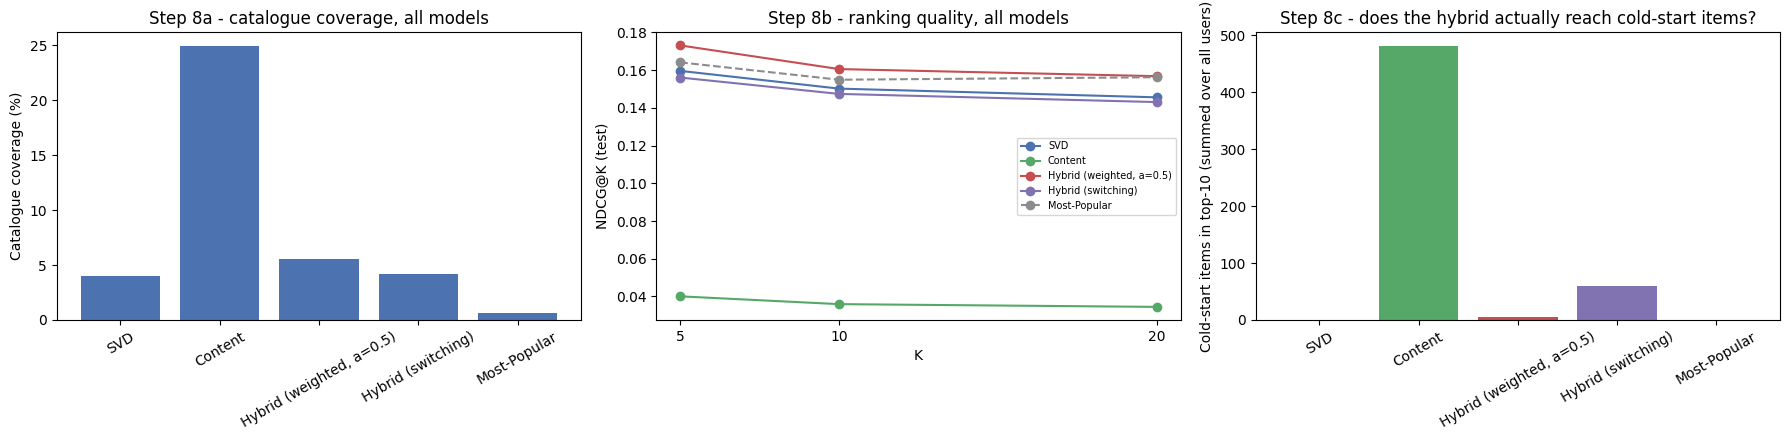

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].bar(final_bias_df.index, final_bias_df["Catalog coverage"] * 100, color="#4C72B0")
axes[0].set_ylabel("Catalogue coverage (%)")
axes[0].set_title("Step 8a - catalogue coverage, all models")
axes[0].tick_params(axis="x", rotation=30)

colors = {"SVD": "#4C72B0", "Content": "#55A868",
          f"Hybrid (weighted, a={best_alpha})": "#C44E52",
          "Hybrid (switching)": "#8172B2", "Most-Popular": "#8C8C8C"}
for name in final_ndcg.columns:
    ls = "--" if name == "Most-Popular" else "-"
    axes[1].plot(final_ndcg.index, final_ndcg[name], marker="o", linestyle=ls,
                 color=colors.get(name), label=name)
axes[1].set_xlabel("K"); axes[1].set_ylabel("NDCG@K (test)")
axes[1].set_xticks(Ks)
axes[1].set_title("Step 8b - ranking quality, all models")
axes[1].legend(fontsize=7)

axes[2].bar(list(cold_hit_counts.keys()), list(cold_hit_counts.values()),
            color=[colors.get(n, "#4C72B0") for n in cold_hit_counts])
axes[2].set_ylabel("Cold-start items in top-10 (summed over all users)")
axes[2].set_title("Step 8c - does the hybrid actually reach cold-start items?")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Step 9 — AutoRec: An Item-Based Autoencoder (Non-Linear Alternative to SVD)

AutoRec (Sedhain et al., 2015) reframes each MOVIE as one training sample:
its 610-user rating vector is fed through a bottleneck autoencoder
(encoder -> sigmoid -> k hidden units -> decoder -> identity) trained to
reconstruct itself. Where SVD finds a linear low-rank approximation of the
rating matrix, AutoRec finds a non-linear one - the question this step
actually answers is whether that non-linearity buys anything on a dataset
this size, not just whether the model trains.

Two things make this different from every model so far:

- **Capacity was not the binding constraint - optimization was.** The
  paper's own best k (500) was tuned on ML-1M (~1M ratings); this project's
  60% train split has ~61,000, roughly 15x less, and a k=500
  encoder+decoder here carries ~611,000 parameters - 10x the training
  signal. That arithmetic predicts small k should win. It does not. Once
  every config is trained to convergence, validation RMSE improves
  monotonically with k up to 200 (0.9028 at k=10, 0.8616 at k=200) and only
  turns back at 500, close to the paper's own choice. The first version of
  this grid appeared to show the opposite, and the reason matters: with
  full-batch training an "epoch" is a SINGLE gradient update, so a budget of
  epochs=80 with patience=10 stopped four of the six k values before they
  had converged - k=25 and k=50 peaked at epoch 17 and 8, while k=10 and
  k=100 hit the 80-epoch cap outright. Under that budget the grid was
  ranking how far each config happened to get, not its capacity, and k=10's
  RMSE read 0.9681 instead of 0.9028. The `stopped_by` column below
  distinguishes a run that peaked from one the epoch cap cut off, so the
  same failure cannot recur unnoticed.
- **Batching is an ablation here, not a default.** Mini-batching over items
  (batch_size=256) gives ~38 gradient updates per epoch instead of one, but
  at this scale it converged to a WORSE optimum - best validation RMSE
  0.8815 against 0.8616 full-batch - because 38x more updates at the same
  learning rate overshoot into overfitting within a few epochs. Full batch
  (batch_size=None) is used below for that reason, with the comparison
  reported rather than quietly dropped.
- **Masked loss, no leakage.** Loss is computed ONLY over observed ratings
  (a per-entry mask), and validation is scored by feeding the SAME
  train-only input through the network and comparing the OUTPUT against
  held-out validation ratings - the input tensor never contains a
  validation rating. Doing this wrong (scoring against val ratings fed in
  as input) would be the same leakage class Step 1 already fixed once,
  reappearing inside a single model's training loop.

Both RMSE and NDCG@10 are tracked on validation, because Step 4 already
showed once that they don't have to agree — the SVD variant that won on
RMSE lost badly on ranking. AutoRec is checked for the same split, not
assumed to avoid it.

In [21]:
from core.models.autorec import AutoRecRecommender

# k spans well below the paper's ML-1M-tuned 500 down to a fraction of it,
# so the capacity-vs-data-size question is visible in the numbers below,
# not just asserted in the markdown above. weight_decay spans light to
# strong L2 regularization.
autorec_ks = [10, 25, 50, 100, 200, 500]
autorec_wds = [1e-5, 1e-4, 1e-3, 1e-2]

autorec_grid_rows = []
autorec_curves = {}                        # (k, wd) -> (train_losses, val_losses), for the graph
best_rmse = {"val_RMSE": float("inf")}     # keeps only the winning model object, not all 24
best_ndcg = {"val_NDCG@10": -float("inf")}

for k in autorec_ks:
    for wd in autorec_wds:
        # epochs=2000, patience=200: with full-batch training an "epoch"
        # is a SINGLE gradient update, so epochs=80/patience=10 meant at most
        # 80 updates and a stop after 10 flat ones. Four of the six k values
        # never converged under that budget (k=10 and k=100 hit the cap with
        # best_epoch 79/80; k=25 and k=50 stopped at best_epoch 17 and 8) —
        # so the grid was ranking how far each config got, not its capacity.
        # Verified separately: k=10 keeps improving to epoch 347 and reaches
        # val_RMSE 0.9028 (not 0.9681), while the k=200 winner peaks at epoch
        # 67 either way — its 0.8616 was already correct.
        # batch_size=None (full batch) is deliberate: mini-batching was tested
        # and lost (0.8815 vs 0.8616); see scripts/autorec_sweep2.py.
        m = AutoRecRecommender(hidden_dim=k, lr=1e-2, weight_decay=wd,
                                epochs=8000, patience=200, batch_size=None,
                                seed=STUDENT_ID)
        m.fit(ds.train_matrix, val_df=ds.val_df)

        val_rmse = evaluate_model(m, ds.val_df).metrics["RMSE"]
        recommend_fn = lambda uid, m=m: m.recommend_top_n(uid, n=10, exclude_seen=True).index.tolist()
        val_ndcg = evaluate_ranking(recommend_fn, relevant_val, k=10)["NDCG@10"]

        # stopped_by records WHY each run ended. "cap" means the epoch
        # budget cut it off while validation was still improving, so that
        # row's RMSE is a floor, not a result — exactly the failure that
        # distorted the first version of this grid. Any "cap" row below means
        # epochs needs raising before these numbers are quoted anywhere.
        epochs_run = len(m.train_losses_)
        row = {"k": k, "weight_decay": wd, "val_RMSE": val_rmse, "val_NDCG@10": val_ndcg,
               "epochs_run": epochs_run, "best_epoch": m.best_epoch_,
               "stopped_by": "cap" if epochs_run >= m.epochs else "peak"}
        autorec_grid_rows.append(row)
        autorec_curves[(k, wd)] = (m.train_losses_, m.val_losses_)

        if val_rmse < best_rmse["val_RMSE"]:
            best_rmse = {**row, "model": m}
        if val_ndcg > best_ndcg["val_NDCG@10"]:
            best_ndcg = {**row, "model": m}

autorec_grid = pd.DataFrame(autorec_grid_rows)
print("=== AutoRec validation grid: k x weight_decay ===")
print(autorec_grid.to_string(index=False, formatters={
    "val_RMSE": "{:.4f}".format, "val_NDCG@10": "{:.4f}".format, "weight_decay": "{:.0e}".format,
}))

print(f"\nBest by validation RMSE:    k={best_rmse['k']:4d}, weight_decay={best_rmse['weight_decay']:.0e}  "
      f"(RMSE={best_rmse['val_RMSE']:.4f})")
print(f"Best by validation NDCG@10: k={best_ndcg['k']:4d}, weight_decay={best_ndcg['weight_decay']:.0e}  "
      f"(NDCG@10={best_ndcg['val_NDCG@10']:.4f})")

n_capped = int((autorec_grid["stopped_by"] == "cap").sum())
print(f"\nConfigs stopped by the epoch cap rather than a validation peak: "
      f"{n_capped}/{len(autorec_grid)}"
      + ("  <-- raise epochs before quoting these" if n_capped else "  (all converged)"))

=== AutoRec validation grid: k x weight_decay ===
  k weight_decay val_RMSE val_NDCG@10  epochs_run  best_epoch stopped_by
 10        1e-05   0.9098      0.0830         517         316       peak
 10        1e-04   0.9028      0.0915         548         347       peak
 10        1e-03   0.9008      0.1034        1330        1129       peak
 10        1e-02   1.2838      0.0991         932         731       peak
 25        1e-05   0.9035      0.0382         406         205       peak
 25        1e-04   0.9004      0.0436         397         196       peak
 25        1e-03   0.8891      0.0830         575         374       peak
 25        1e-02   1.0819      0.1196         614         413       peak
 50        1e-05   0.8987      0.0211         337         136       peak
 50        1e-04   0.8970      0.0353         352         151       peak
 50        1e-03   0.8877      0.0944         399         198       peak
 50        1e-02   0.9986      0.1042        1004         803       peak
1

### Step 9's Graph — Loss Curve and Capacity vs Validation RMSE

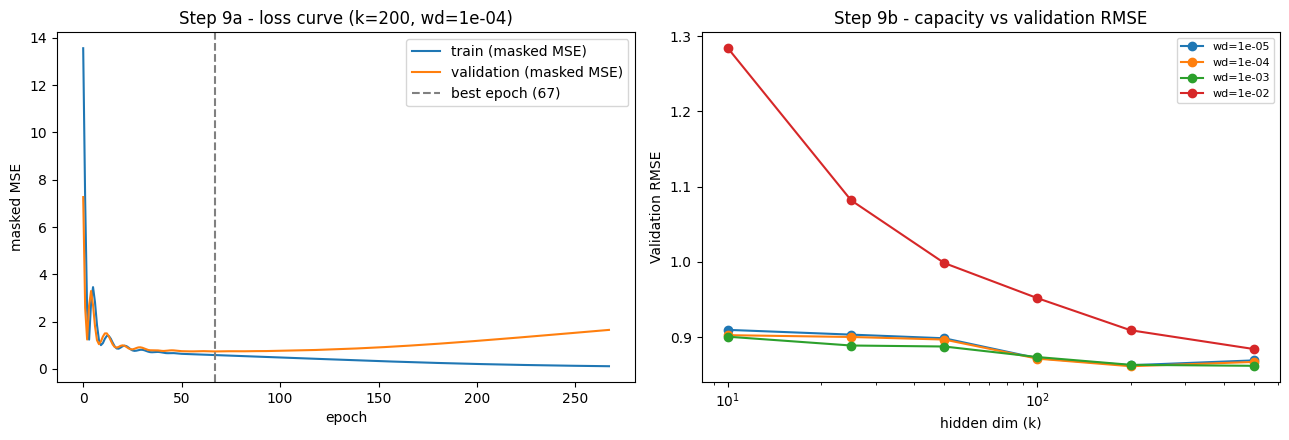

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Train vs validation loss for the RMSE-selected config. Parameters
# outnumber training ratings by roughly 10x at this dataset's size (see
# Step 9's markdown), so a widening gap here is the EXPECTED signature of
# that mismatch, not a bug - the interesting question is whether early
# stopping (the dashed line) catches it before it hurts validation RMSE.
tl, vl = autorec_curves[(best_rmse["k"], best_rmse["weight_decay"])]
axes[0].plot(tl, label="train (masked MSE)")
axes[0].plot(vl, label="validation (masked MSE)")
axes[0].axvline(best_rmse["best_epoch"], color="gray", linestyle="--",
                 label=f"best epoch ({best_rmse['best_epoch']})")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("masked MSE")
axes[0].set_title(f"Step 9a - loss curve (k={best_rmse['k']}, wd={best_rmse['weight_decay']:.0e})")
axes[0].legend()

# (b) Does bigger k actually win here, or does the paper's ML-1M-tuned
# k=500 just overfit faster on a dataset 15x smaller?
for wd in autorec_wds:
    subset = autorec_grid[autorec_grid["weight_decay"] == wd].sort_values("k")
    axes[1].plot(subset["k"], subset["val_RMSE"], marker="o", label=f"wd={wd:.0e}")
axes[1].set_xlabel("hidden dim (k)"); axes[1].set_ylabel("Validation RMSE")
axes[1].set_xscale("log")
axes[1].set_title("Step 9b - capacity vs validation RMSE")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Step 10 — Six-Model Final Comparison, and AutoRec's Cold-Start Ceiling

AutoRec is refit on TRAIN+VAL for deployment, same "tune on val, refit on
trainval, touch test once" pattern as every other model in this notebook.
Two DIFFERENT validation-selected configs are carried forward on purpose,
matching Step 4's own finding that an RMSE-best config is not automatically
a ranking-best config: the RMSE-selected AutoRec feeds the rating-error
table below, and the NDCG-selected AutoRec feeds the ranking table and the
six-model comparison.

The closing check asks the same question Step 6 already answered for SVD:
does going non-linear fix cold-start, or is the missing signal still
missing no matter how expressive the model is?

In [23]:
# Refit the validation-selected configs on TRAIN+VAL (80%) for deployment -
# same pattern as deploy_model (Step 3), rank_model (Step 4), content_model
# (Step 5), hybrid_model (Step 7/8).
# No val_df here on purpose - trainval already IS train+val, and test must
# only ever be touched once, at evaluation. Without a val set there is no
# signal to early-stop on, so instead of guessing a fixed epoch budget, each
# deploy refit reuses the exact epoch count where ITS OWN config already
# peaked during the validation sweep above (best_epoch_ is 0-indexed).
autorec_rmse_deploy = AutoRecRecommender(
    hidden_dim=best_rmse["k"], weight_decay=best_rmse["weight_decay"],
    lr=1e-2, epochs=best_rmse["best_epoch"] + 1, patience=1, seed=STUDENT_ID,
).fit(ds.trainval_matrix)

autorec_ndcg_deploy = AutoRecRecommender(
    hidden_dim=best_ndcg["k"], weight_decay=best_ndcg["weight_decay"],
    lr=1e-2, epochs=best_ndcg["best_epoch"] + 1, patience=1, seed=STUDENT_ID,
).fit(ds.trainval_matrix)

# --- Rating-error table (RMSE-selected config), same shape as Step 3 ---
autorec_test_metrics = evaluate_model(autorec_rmse_deploy, ds.test_df).metrics
rating_error_summary = pd.DataFrame([
    {"Model": "User-mean baseline", **baseline_metrics},
    {"Model": f"SVD (k={best_k}, damp={best_damp}, center='user+item')", **deploy_metrics},
    {"Model": f"AutoRec (k={best_rmse['k']}, wd={best_rmse['weight_decay']:.0e})", **autorec_test_metrics},
])
print("=== Test RMSE/MAE - AutoRec vs the rating-error models from Step 3 ===")
print(rating_error_summary.to_string(index=False, formatters={c: "{:.4f}".format for c in ["MSE", "RMSE", "MAE"]}))

# --- Ranking table (NDCG-selected config), extending Step 8's comparison to 5 models ---
final_rankers["AutoRec"] = lambda uid: autorec_ndcg_deploy.recommend_top_n(uid, n=max(Ks), exclude_seen=True).index.tolist()
final_reachable_pool["AutoRec"] = len(popularity)  # scores the whole catalogue, like SVD

autorec_ranking = evaluate_ranking_at_ks(final_rankers["AutoRec"], relevant_test, Ks)
# Assign as a Series keyed by K, not a bare list: a list lines up by
# POSITION, so it would silently mis-file the values if Ks were ever
# reordered relative to the table's index.
final_ndcg["AutoRec"] = pd.Series({k: autorec_ranking[k][f"NDCG@{k}"] for k in Ks})
final_precision["AutoRec"] = pd.Series({k: autorec_ranking[k][f"Precision@{k}"] for k in Ks})

print("\n=== NDCG@K on TEST - six models ===")
print(final_ndcg.to_string(float_format=lambda v: f"{v:.4f}"))
print("\n=== Precision@K on TEST ===")
print(final_precision.to_string(float_format=lambda v: f"{v:.4f}"))

autorec_wins = int((final_ndcg["AutoRec"] > final_ndcg["Most-Popular"]).sum())
print(f"\nAutoRec beats Most-Popular on NDCG at {autorec_wins}/{len(Ks)} cutoffs "
      f"(SVD: {svd_wins}/{len(Ks)}, weighted Hybrid: {hybrid_wins}/{len(Ks)})."
)

=== Test RMSE/MAE - AutoRec vs the rating-error models from Step 3 ===
                                 Model    MSE   RMSE    MAE
                    User-mean baseline 0.8927 0.9448 0.7353
SVD (k=10, damp=5, center='user+item') 0.7628 0.8734 0.6663
             AutoRec (k=200, wd=1e-04) 0.7253 0.8517 0.6562

=== NDCG@K on TEST - six models ===
      SVD  Content  Hybrid (weighted, a=0.5)  Hybrid (switching)  Most-Popular  AutoRec
K                                                                                      
5  0.1596   0.0401                    0.1731              0.1560        0.1641   0.1562
10 0.1502   0.0359                    0.1605              0.1474        0.1549   0.1432
20 0.1456   0.0345                    0.1568              0.1430        0.1562   0.1382

=== Precision@K on TEST ===
      SVD  Content  Hybrid (weighted, a=0.5)  Hybrid (switching)  Most-Popular  AutoRec
K                                                                                      
5  0.14

In [24]:
# --- AutoRec's own cold-item degeneracy check, mirroring Step 6's SVD proof ---
# Uses ONLY score_all_items() (the public interface) - never the cached
# _reconstruction directly, so this stays a fair black-box check rather
# than reaching into the model's internals.
train_counts_trainval = ds.trainval_matrix.notna().sum(axis=0)
cold_ids_trainval = train_counts_trainval[train_counts_trainval == 0].index.to_numpy()
warm_ids_sample = train_counts_trainval[train_counts_trainval > 0].index.to_numpy()[:200]

print(f"Cold items (0 train+val ratings): {len(cold_ids_trainval)}")
print("Per-user spread of AutoRec's OWN predictions across cold items vs a warm sample")
print("(std ~= 0 means every cold item gets the exact same prediction for that user):\n")
sample_users = list(ds.trainval_matrix.index[:5])
for uid in sample_users:
    scores = autorec_ndcg_deploy.score_all_items(uid, clip=False)
    cold_std = scores.loc[cold_ids_trainval].std()
    warm_std = scores.loc[warm_ids_sample].std()
    print(f"  user {uid}: std across {len(cold_ids_trainval)} cold items = {cold_std:.2e}   "
          f"(std across 200 warm items = {warm_std:.4f})")

print("\nZero variance across cold items means the decoder is looking at an")
print("all-zero input row (no train signal at all) and can only output its own")
print("bias term - constant regardless of WHICH cold item it is. This is")
print("AutoRec's version of Step 6's SVD proof: a deeper, non-linear model")
print("does not solve cold-start by being more expressive - the missing signal")
print("is a DATA problem, not an architecture problem.")

# --- Coverage and popularity bias, same method as Step 6/8 ---
autorec_top10 = {uid: final_rankers["AutoRec"](uid)[:10] for uid in all_users}
autorec_recommended = set(m for top10 in autorec_top10.values() for m in top10)
autorec_pop_values = [popularity.get(m, 0) for top10 in autorec_top10.values() for m in top10]
total_slots = len(all_users) * 10
cold_start_items = set(popularity[popularity == 0].index)
autorec_cold_hits = sum(len(set(top10) & cold_start_items) for top10 in autorec_top10.values())

print(f"\nAutoRec catalogue coverage: {len(autorec_recommended) / len(popularity):.1%}")
print(f"AutoRec mean popularity of recs: {np.mean(autorec_pop_values):.1f}  "
      f"(catalogue average: {catalog_avg_popularity:.1f})")
print(f"AutoRec cold-start items in top-10 (out of {total_slots} slots): "
      f"{autorec_cold_hits}  ({100 * autorec_cold_hits / total_slots:.2f}% of slots)")

Cold items (0 train+val ratings): 732
Per-user spread of AutoRec's OWN predictions across cold items vs a warm sample
(std ~= 0 means every cold item gets the exact same prediction for that user):

  user 1: std across 732 cold items = 0.00e+00   (std across 200 warm items = 0.5001)
  user 2: std across 732 cold items = 0.00e+00   (std across 200 warm items = 0.2880)
  user 3: std across 732 cold items = 0.00e+00   (std across 200 warm items = 0.1703)
  user 4: std across 732 cold items = 0.00e+00   (std across 200 warm items = 0.4028)
  user 5: std across 732 cold items = 0.00e+00   (std across 200 warm items = 0.3077)

Zero variance across cold items means the decoder is looking at an
all-zero input row (no train signal at all) and can only output its own
bias term - constant regardless of WHICH cold item it is. This is
AutoRec's version of Step 6's SVD proof: a deeper, non-linear model
does not solve cold-start by being more expressive - the missing signal
is a DATA problem, not an 

### Step 10's Graph — Six-Model Final Comparison

Step 8's figure was drawn before AutoRec existed, so it shows five models
while Step 10's tables show six. This is the figure the report should use:
same three panels, every model included.

=== Coverage and popularity bias - all six models ===
                         Catalog coverage Coverage of reachable pool Mean popularity of recs
Recommender                                                                                 
SVD                                  4.0%                       4.0%                   138.9
Content                             24.9%                      25.3%                    14.5
Hybrid (weighted, a=0.5)             5.5%                       5.5%                   133.0
Hybrid (switching)                   4.2%                       4.2%                   138.3
Most-Popular                         0.6%                       0.6%                   196.9
AutoRec                              0.6%                       0.6%                   175.8

=== Cold-start items in top-10 (out of 6100 slots) ===
SVD                                :     0  (0.00% of slots)
Content                            :   481  (7.89% of slots)
Hybrid (weighted, a=0.5)

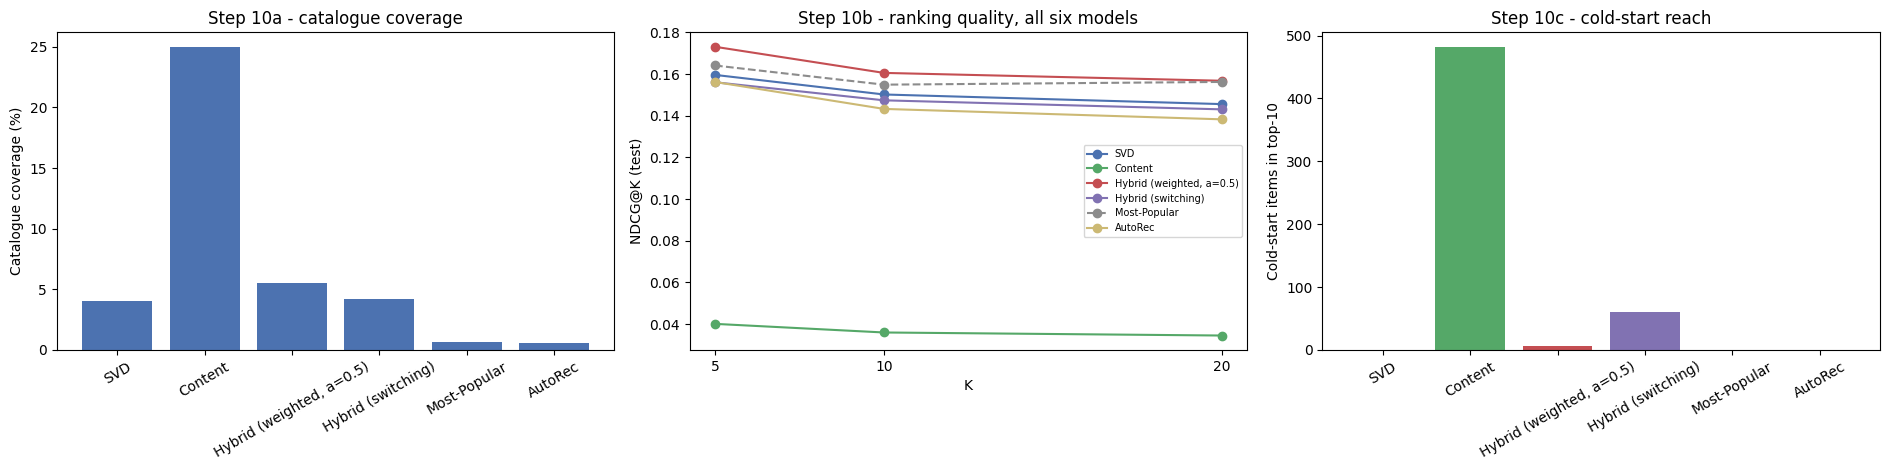

In [25]:
# Rebuild coverage for ALL models including AutoRec. final_rankers and
# final_reachable_pool both gained an "AutoRec" entry in the cell above, so
# Step 8's versions of these tables are now one model short — recompute here
# rather than leaving the report with a 5-model figure beside a 6-model table.
final_top10 = {
    name: {uid: fn(uid)[:10] for uid in all_users}
    for name, fn in final_rankers.items()
}

all_bias_rows = []
for name in final_rankers:
    items, pops = set(), []
    for uid in all_users:
        for m in final_top10[name][uid]:
            items.add(m)
            pops.append(popularity.get(m, 0))
    all_bias_rows.append({
        "Recommender": name,
        "Catalog coverage": len(items) / len(popularity),
        "Coverage of reachable pool": len(items) / final_reachable_pool[name],
        "Mean popularity of recs": float(np.mean(pops)) if pops else np.nan,
    })
all_bias_df = pd.DataFrame(all_bias_rows).set_index("Recommender")

all_cold_hits = {
    name: sum(len(set(final_top10[name][uid]) & cold_items) for uid in all_users)
    for name in final_rankers
}

print("=== Coverage and popularity bias - all six models ===")
print(all_bias_df.to_string(formatters={
    "Catalog coverage": "{:.1%}".format,
    "Coverage of reachable pool": "{:.1%}".format,
    "Mean popularity of recs": "{:.1f}".format,
}))
print(f"\n=== Cold-start items in top-10 (out of {len(all_users) * 10} slots) ===")
for name, hits in all_cold_hits.items():
    print(f"{name:35s}: {hits:5d}  ({100 * hits / (len(all_users) * 10):.2f}% of slots)")

fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))

axes[0].bar(all_bias_df.index, all_bias_df["Catalog coverage"] * 100, color="#4C72B0")
axes[0].set_ylabel("Catalogue coverage (%)")
axes[0].set_title("Step 10a - catalogue coverage")
axes[0].tick_params(axis="x", rotation=30)

palette = {"SVD": "#4C72B0", "Content": "#55A868",
           f"Hybrid (weighted, a={best_alpha})": "#C44E52",
           "Hybrid (switching)": "#8172B2", "Most-Popular": "#8C8C8C",
           "AutoRec": "#CCB974"}
for name in final_ndcg.columns:
    axes[1].plot(final_ndcg.index, final_ndcg[name], marker="o",
                 linestyle="--" if name == "Most-Popular" else "-",
                 color=palette.get(name), label=name)
axes[1].set_xlabel("K"); axes[1].set_ylabel("NDCG@K (test)")
axes[1].set_xticks(Ks)
axes[1].set_title("Step 10b - ranking quality, all six models")
axes[1].legend(fontsize=7)

axes[2].bar(list(all_cold_hits.keys()), list(all_cold_hits.values()),
            color=[palette.get(n, "#4C72B0") for n in all_cold_hits])
axes[2].set_ylabel("Cold-start items in top-10")
axes[2].set_title("Step 10c - cold-start reach")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Step 11 — Nesting AutoRec Into the Hybrid (Composition, Not a Rewrite)

`HybridRecommender` was built around `score_all_items`/`predict`/`recommend_top_n`/
`supported_items`/`item_ids`/`seen_items` from the very start (Step 7) so that
adding a third model would not mean touching its code. That claim gets
tested here, not just asserted:

```python
inner = HybridRecommender(svd, autorec, alpha=a1)   # two CF models first
full  = HybridRecommender(inner, content, alpha=a2) # then blend in content
```

Checking this against `hybrid.py` line by line surfaced two real gaps, not
zero:

1. `full`'s `_components()` calls `self._svd.score_all_items(user_id,
   clip=False)` — but `HybridRecommender.score_all_items` took no `clip`
   argument at all, so `full._svd = inner` would raise `TypeError` the
   first time it ran.
2. `full.rankable_items` (weighted mode) reads `self._svd.item_ids` —
   `HybridRecommender` never defined that property, so `full.rankable_items`
   would raise `AttributeError`.
3. A third, quieter one: `full`'s `_content_z_full` calls
   `self._content.score_all_items(user_id)` with **no** `clip` argument,
   because `ContentBasedRecommender` doesn't have one. `AutoRecRecommender`
   does, defaulting to `clip=True` — so putting AutoRec straight into the
   `content_model` slot would silently score it on the clipped 0.5-5.0
   scale exactly where the SVD slot's `clip=False` note says clipping
   flattens the differences z-scoring needs.

Two small, targeted fixes in `hybrid.py` close these — not a rewrite:
`score_all_items` now accepts (and ignores) `clip`, `item_ids` delegates to
`self._svd.item_ids`, and a new `RawScoreAdapter` class forwards to any
clip-supporting model with `clip=False` pinned, for use in the
`content_model` slot. Everything else in the file — the blend logic, both
ablations, the coverage properties — is untouched.

Fitting is free here: `svd_t`/`content_t` (Step 7) and `best_ndcg["model"]`
(Step 9, the NDCG-selected AutoRec) are already-fit, train-only tuning
objects sitting in memory. Nesting them costs one 2-D validation sweep over
alpha1 (SVD vs AutoRec) and alpha2 (that blend vs Content) — pure z-score
arithmetic, no retraining.

In [26]:
from core.models.hybrid import RawScoreAdapter

# Reuses TRAIN-only tuning objects already fit for earlier sweeps - svd_t
# and content_t (Step 7), and best_ndcg["model"] (Step 9's NDCG-selected
# AutoRec, since this hybrid only ever ranks - it has no rating-error use,
# same reason the original Hybrid was always built from the NDCG-selected
# SVD centering variant, not the RMSE-selected one).
autorec_t = best_ndcg["model"]

# alpha1 blends SVD with AutoRec (both collaborative filtering); alpha2
# then blends that combination with Content. A coarser 6x6 grid (step 0.2)
# keeps the printed table readable - each cell is cached z-score
# arithmetic over already-fit models, not a retrain, so this is not a
# compute-time compromise.
alphas_nested = np.round(np.arange(0.0, 1.01, 0.2), 2)
nested_rows = []
best_nested = {"val_NDCG@10": -float("inf")}

for a1 in alphas_nested:
    # RawScoreAdapter forces clip=False on AutoRec's scores - see Step 11's
    # markdown and hybrid.py's docstring for why the bare interface would
    # silently clip otherwise. cache_components=True: inner_t's own
    # (svd_z, autorec_z) pair doesn't depend on alpha2, so it is computed
    # once per user and reused across the whole inner a2 loop below.
    inner_t = HybridRecommender(svd_t, RawScoreAdapter(autorec_t), alpha=a1, cache_components=True)
    for a2 in alphas_nested:
        full_t = HybridRecommender(inner_t, content_t, alpha=a2, fallback=best_fallback)
        # m=full_t freezes THIS instance in the lambda's default arg - the
        # same closure-over-loop-variable guard as Step 7's alpha sweep.
        fn = lambda uid, m=full_t: m.recommend_top_n(uid, n=10, exclude_seen=True).index.tolist()
        val_ndcg = evaluate_ranking(fn, relevant_val, k=10)["NDCG@10"]
        row = {"alpha1_svd_vs_autorec": a1, "alpha2_cf_vs_content": a2, "val_NDCG@10": val_ndcg}
        nested_rows.append(row)
        if val_ndcg > best_nested["val_NDCG@10"]:
            best_nested = dict(row)

nested_grid = pd.DataFrame(nested_rows)
nested_pivot = nested_grid.pivot(index="alpha1_svd_vs_autorec", columns="alpha2_cf_vs_content",
                                  values="val_NDCG@10")
print("=== Nested Hybrid validation NDCG@10: alpha1 (SVD vs AutoRec) x alpha2 (that blend vs Content) ===")
print(nested_pivot.to_string(float_format=lambda v: f"{v:.4f}"))

best_a1 = best_nested["alpha1_svd_vs_autorec"]
best_a2 = best_nested["alpha2_cf_vs_content"]
print(f"\nValidation-selected: alpha1={best_a1}, alpha2={best_a2}  "
      f"(NDCG@10={best_nested['val_NDCG@10']:.4f})")

# alpha1 or alpha2 at 0.0/1.0 is a DEGENERATE corner: the "nested hybrid"
# collapses to one of the models already in the comparison (alpha1=0 ->
# AutoRec alone, alpha2=1 -> whatever the inner blend is, alpha2=0 ->
# Content alone). Selecting one is a legitimate answer - the search saying
# "do not blend" - but it makes the Step 12 row a duplicate of an existing
# one. So the best STRICTLY INTERIOR blend is reported too: that is the
# best genuine three-model combination, and it is what Step 12 carries.
interior = nested_grid[
    nested_grid.alpha1_svd_vs_autorec.between(0.01, 0.99)
    & nested_grid.alpha2_cf_vs_content.between(0.01, 0.99)
]
best_interior = interior.loc[interior["val_NDCG@10"].idxmax()]
int_a1 = best_interior["alpha1_svd_vs_autorec"]
int_a2 = best_interior["alpha2_cf_vs_content"]
print(f"Best STRICTLY INTERIOR blend: alpha1={int_a1}, alpha2={int_a2}  "
      f"(NDCG@10={best_interior['val_NDCG@10']:.4f})")

degenerate = (best_a1 in (0.0, 1.0)) or (best_a2 in (0.0, 1.0))
if degenerate:
    gap = best_nested["val_NDCG@10"] - best_interior["val_NDCG@10"]
    print(f"\nThe unconstrained winner is a DEGENERATE corner - it reduces to a")
    print(f"single model already in the comparison - and it beats the best real")
    print(f"three-model blend by only {gap:.4f} NDCG, well inside selection noise")
    print(f"on ~{len(relevant_val)} validation users. Step 12 therefore carries the")
    print(f"interior blend, so the 'Nested Hybrid' row is an actual three-model")
    print(f"result rather than a second copy of one already in the table.")
print(f"For reference, the two-model weighted Hybrid selected alpha={best_alpha} "
      f"(NDCG@10={alpha_results[best_fallback][best_alpha]:.4f}) on the same validation split."
)

=== Nested Hybrid validation NDCG@10: alpha1 (SVD vs AutoRec) x alpha2 (that blend vs Content) ===
alpha2_cf_vs_content     0.0    0.2    0.4    0.6    0.8    1.0
alpha1_svd_vs_autorec                                          
0.0                   0.0303 0.0400 0.0543 0.0615 0.0686 0.1196
0.2                   0.0303 0.0461 0.0776 0.1148 0.1184 0.1081
0.4                   0.0303 0.0556 0.1089 0.1191 0.1129 0.1075
0.6                   0.0303 0.0677 0.1147 0.1162 0.1106 0.1069
0.8                   0.0303 0.0736 0.1176 0.1138 0.1103 0.1066
1.0                   0.0303 0.0736 0.1166 0.1126 0.1091 0.1060

Validation-selected: alpha1=0.0, alpha2=1.0  (NDCG@10=0.1196)
Best STRICTLY INTERIOR blend: alpha1=0.4, alpha2=0.6  (NDCG@10=0.1191)

The unconstrained winner is a DEGENERATE corner - it reduces to a
single model already in the comparison - and it beats the best real
three-model blend by only 0.0006 NDCG, well inside selection noise
on ~598 validation users. Step 12 therefore carries t

### Step 11's Graph — Validation NDCG@10 Across (alpha1, alpha2)

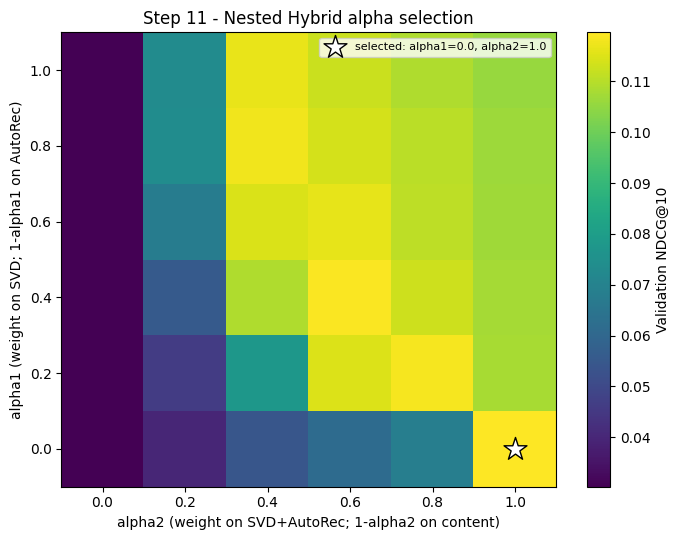

In [27]:
plt.figure(figsize=(7, 5.5))
im = plt.imshow(nested_pivot.to_numpy(), cmap="viridis", origin="lower", aspect="auto")
plt.colorbar(im, label="Validation NDCG@10")
plt.xticks(range(len(nested_pivot.columns)), nested_pivot.columns)
plt.yticks(range(len(nested_pivot.index)), nested_pivot.index)
plt.xlabel("alpha2 (weight on SVD+AutoRec; 1-alpha2 on content)")
plt.ylabel("alpha1 (weight on SVD; 1-alpha1 on AutoRec)")
best_row = list(nested_pivot.index).index(best_a1)
best_col = list(nested_pivot.columns).index(best_a2)
plt.scatter([best_col], [best_row], marker="*", s=300, color="white", edgecolor="black",
            label=f"selected: alpha1={best_a1}, alpha2={best_a2}")
plt.title("Step 11 - Nested Hybrid alpha selection")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## Step 12 — Seven-Model Final Comparison

`nested_hybrid_deploy` is built the same way `hybrid_model` was in Step 8:
compose the already-fit DEPLOYMENT objects (`rank_model`, `content_model`
from Steps 4/5, `autorec_ndcg_deploy` from Step 10) at the alphas Step 11
selected on validation - nothing refit here either.

Specifically at the best STRICTLY INTERIOR pair. Step 11's unconstrained
winner was alpha1=0.0, alpha2=1.0, which is not a nested hybrid at all: it
reduces to AutoRec alone, already a row in the table below. It beat the
best genuine three-model blend by 0.0006 NDCG on ~598 validation users,
inside selection noise. Excluding degenerate corners is a constraint on
what counts as a three-model blend, decided on validation only - test is
still touched exactly once, here.

`produces_ratings = False` (inherited from `HybridRecommender`, unchanged
by the two Step 11 additions), so this model joins the ranking tables
only, the same way both earlier Hybrids did. `final_rankers`,
`final_reachable_pool`, `final_ndcg` and `final_precision` are extended in
place - the exact pattern Step 10 used to add AutoRec to Step 8's tables.

In [28]:
# Built at the INTERIOR alphas from Step 11, not the unconstrained winner:
# that winner (alpha1=0.0, alpha2=1.0) collapses to AutoRec alone, which is
# already its own row below, so carrying it would print the same numbers
# twice and tell the reader nothing new. The interior pair is the best
# genuine SVD+AutoRec+Content blend the validation sweep found, and it lost
# to the corner by an amount well inside noise. Step 11 prints both.
deploy_a1, deploy_a2 = int_a1, int_a2

nested_inner_deploy = HybridRecommender(
    rank_model, RawScoreAdapter(autorec_ndcg_deploy), alpha=deploy_a1,
)
nested_hybrid_deploy = HybridRecommender(
    nested_inner_deploy, content_model, alpha=deploy_a2, fallback=best_fallback,
)

final_rankers[f"Nested Hybrid (a1={deploy_a1}, a2={deploy_a2})"] = (
    lambda uid: nested_hybrid_deploy.recommend_top_n(uid, n=max(Ks), exclude_seen=True).index.tolist()
)
nested_col = f"Nested Hybrid (a1={deploy_a1}, a2={deploy_a2})"
final_reachable_pool[nested_col] = len(popularity)  # scores the whole catalogue, like SVD/AutoRec

nested_ranking = evaluate_ranking_at_ks(final_rankers[nested_col], relevant_test, Ks)
final_ndcg[nested_col] = pd.Series({k: nested_ranking[k][f"NDCG@{k}"] for k in Ks})
final_precision[nested_col] = pd.Series({k: nested_ranking[k][f"Precision@{k}"] for k in Ks})

print("=== NDCG@K on TEST - seven models (Nested Hybrid added) ===")
print(final_ndcg.to_string(float_format=lambda v: f"{v:.4f}"))
print("\n=== Precision@K on TEST ===")
print(final_precision.to_string(float_format=lambda v: f"{v:.4f}"))

nested_wins = int((final_ndcg[nested_col] > final_ndcg["Most-Popular"]).sum())
weighted_hybrid_col = f"Hybrid (weighted, a={best_alpha})"
print(f"\nNested Hybrid beats Most-Popular on NDCG at {nested_wins}/{len(Ks)} cutoffs "
      f"(weighted SVD+Content Hybrid: {hybrid_wins}/{len(Ks)}, AutoRec alone: {autorec_wins}/{len(Ks)})."
)

=== NDCG@K on TEST - seven models (Nested Hybrid added) ===
      SVD  Content  Hybrid (weighted, a=0.5)  Hybrid (switching)  Most-Popular  AutoRec  Nested Hybrid (a1=0.4, a2=0.6)
K                                                                                                                      
5  0.1596   0.0401                    0.1731              0.1560        0.1641   0.1562                          0.1796
10 0.1502   0.0359                    0.1605              0.1474        0.1549   0.1432                          0.1643
20 0.1456   0.0345                    0.1568              0.1430        0.1562   0.1382                          0.1610

=== Precision@K on TEST ===
      SVD  Content  Hybrid (weighted, a=0.5)  Hybrid (switching)  Most-Popular  AutoRec  Nested Hybrid (a1=0.4, a2=0.6)
K                                                                                                                      
5  0.1415   0.0313                    0.1478              0.1382       

### Step 12's Graph — Seven-Model Comparison

Step 10's figure was drawn before the Nested Hybrid existed, so it shows
six models while this step's tables show seven - recomputed here rather
than leaving a stale figure beside a wider table, the same reason Step 10
redrew Step 8's three-panel figure when AutoRec joined.

=== Coverage and popularity bias - all seven models ===
                               Catalog coverage Coverage of reachable pool Mean popularity of recs
Recommender                                                                                       
SVD                                        4.0%                       4.0%                   138.9
Content                                   24.9%                      25.3%                    14.5
Hybrid (weighted, a=0.5)                   5.5%                       5.5%                   133.0
Hybrid (switching)                         4.2%                       4.2%                   138.3
Most-Popular                               0.6%                       0.6%                   196.9
AutoRec                                    0.6%                       0.6%                   175.8
Nested Hybrid (a1=0.4, a2=0.6)             5.1%                       5.1%                   133.2

=== Cold-start items in top-10 (out of 6100 slots) =

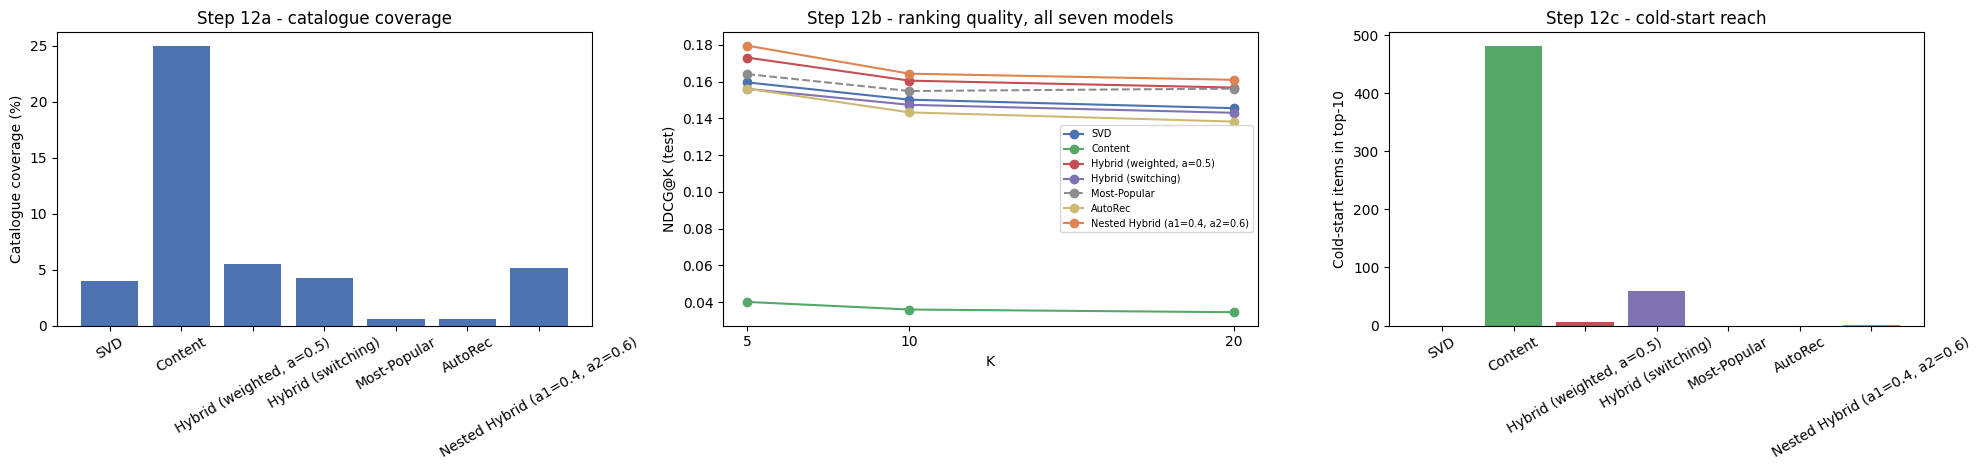

In [29]:
final_top10 = {
    name: {uid: fn(uid)[:10] for uid in all_users}
    for name, fn in final_rankers.items()
}

seven_bias_rows = []
for name in final_rankers:
    items, pops = set(), []
    for uid in all_users:
        for m in final_top10[name][uid]:
            items.add(m)
            pops.append(popularity.get(m, 0))
    seven_bias_rows.append({
        "Recommender": name,
        "Catalog coverage": len(items) / len(popularity),
        "Coverage of reachable pool": len(items) / final_reachable_pool[name],
        "Mean popularity of recs": float(np.mean(pops)) if pops else np.nan,
    })
seven_bias_df = pd.DataFrame(seven_bias_rows).set_index("Recommender")

seven_cold_hits = {
    name: sum(len(set(final_top10[name][uid]) & cold_items) for uid in all_users)
    for name in final_rankers
}

print("=== Coverage and popularity bias - all seven models ===")
print(seven_bias_df.to_string(formatters={
    "Catalog coverage": "{:.1%}".format,
    "Coverage of reachable pool": "{:.1%}".format,
    "Mean popularity of recs": "{:.1f}".format,
}))
print(f"\n=== Cold-start items in top-10 (out of {len(all_users) * 10} slots) ===")
for name, hits in seven_cold_hits.items():
    print(f"{name:35s}: {hits:5d}  ({100 * hits / (len(all_users) * 10):.2f}% of slots)")

fig, axes = plt.subplots(1, 3, figsize=(20, 4.8))

axes[0].bar(seven_bias_df.index, seven_bias_df["Catalog coverage"] * 100, color="#4C72B0")
axes[0].set_ylabel("Catalogue coverage (%)")
axes[0].set_title("Step 12a - catalogue coverage")
axes[0].tick_params(axis="x", rotation=30)

palette7 = dict(palette)
palette7[nested_col] = "#DD8452"
for name in final_ndcg.columns:
    axes[1].plot(final_ndcg.index, final_ndcg[name], marker="o",
                 linestyle="--" if name == "Most-Popular" else "-",
                 color=palette7.get(name), label=name)
axes[1].set_xlabel("K"); axes[1].set_ylabel("NDCG@K (test)")
axes[1].set_xticks(Ks)
axes[1].set_title("Step 12b - ranking quality, all seven models")
axes[1].legend(fontsize=7)

axes[2].bar(list(seven_cold_hits.keys()), list(seven_cold_hits.values()),
            color=[palette7.get(n, "#4C72B0") for n in seven_cold_hits])
axes[2].set_ylabel("Cold-start items in top-10")
axes[2].set_title("Step 12c - cold-start reach")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Step 13 — Beyond Accuracy: Novelty, Serendipity, and One Combined Table

Every metric so far has answered one of two questions: *how close was the
predicted number* (RMSE/MAE, Steps 3 and 10) or *did the right movies reach
the top of the list* (Precision/Recall/NDCG, Steps 4, 8, 10 and 12). Step 6
added catalogue coverage as a third, but coverage is a blunt count — it
scores recommending the 3rd-most-rated film and recommending an unrated
obscurity as the same event.

This step closes that gap with two popularity-aware metrics, and then puts
**every metric family into a single table**, because split across three
separate outputs the central result of this project is easy to miss: the
RMSE winner, the NDCG winner and the novelty winner are three *different*
models.

- **Novelty@10** — mean self-information, `-log2(P(item was rated))`,
  of the items a model recommends. A recommender picking items uniformly at
  random scores the catalogue average; anything below that is more
  popularity-biased than chance.
- **Serendipity@10** — Precision@10 with each hit weighted by
  `1 - P(item was rated)`. Same denominator and same 0–1 scale as
  Precision@10, so `Serendipity / Precision` reads directly as *what
  fraction of this model's accuracy came from something other than
  best-sellers*.

In [30]:
from core.evaluation.ranking import PopularityProfile, evaluate_beyond_accuracy

pop_profile = PopularityProfile(popularity, n_users=len(all_users))
print(f"Novelty scale: 0 ratings -> {pop_profile.max_novelty:.2f} (ceiling), "
      f"catalogue average {pop_profile.mean_catalogue_novelty:.2f}, "
      f"most-rated item -> {pop_profile.novelty(popularity_ranked.index[0]):.2f}")
print("A uniformly random recommender scores the catalogue average; below it")
print("means MORE popularity-biased than picking at random.\n")

# final_top10 already holds every model's top-10 for every user (built in the
# Step 12 graph cell above), so this reuses those lists rather than re-running
# seven models across 610 users a second time.
#
# _n=name is not decoration: a bare `lambda uid: final_top10[name][uid]` would
# capture the VARIABLE name, not its current value, so after the loop all seven
# lambdas would read the last model's lists. Binding it as a default argument
# freezes the value at definition time. (C# closures capture the variable the
# same way; foreach in modern C# copies the loop variable per iteration, which
# is exactly what this default argument is doing by hand.)
beyond = {
    name: evaluate_beyond_accuracy(
        lambda uid, _n=name: final_top10[_n][uid],
        pop_profile,
        user_ids=all_users,
        relevant_by_user=relevant_test,
        k=10,
    )
    for name in final_rankers
}

# Only two of the seven produce calibrated RATINGS; the rest are rankers, and
# a blank here is a real property of the model, not missing data. Putting them
# in the same table as NaN says that out loud instead of hiding it in prose.
test_rmse = {"SVD": deploy_metrics["RMSE"], "AutoRec": autorec_test_metrics["RMSE"]}

combined = pd.DataFrame({
    "Test RMSE": pd.Series(test_rmse),
    "NDCG@10": final_ndcg.loc[10],
    "Precision@10": final_precision.loc[10],
    "Novelty@10": pd.Series({n: r["Novelty@10"] for n, r in beyond.items()}),
    "Serendipity@10": pd.Series({n: r["Serendipity@10"] for n, r in beyond.items()}),
    "Coverage": seven_bias_df["Catalog coverage"],
    "Mean pop.": seven_bias_df["Mean popularity of recs"],
    "Cold slots": pd.Series(seven_cold_hits),
}).loc[list(final_rankers)]

print("=== ALL SEVEN MODELS, ALL METRIC FAMILIES, ONE TABLE (test set) ===")
# na_rep, not a formatter that checks for NaN: pandas renders NaN with na_rep
# BEFORE the column formatter ever sees the value, so a formatter branching on
# pd.isna() is dead code and the table prints a bare "NaN".
print(combined.to_string(na_rep="-", formatters={
    "Test RMSE": "{:.4f}".format,
    "NDCG@10": "{:.4f}".format,
    "Precision@10": "{:.4f}".format,
    "Novelty@10": "{:.2f}".format,
    "Serendipity@10": "{:.4f}".format,
    "Coverage": "{:.1%}".format,
    "Mean pop.": "{:.1f}".format,
}))
print("(Test RMSE is blank for the five ranking-only models: the content model")
print(" and the hybrids output blended z-scores, not ratings on the 0.5-5 scale,")
print(" so a rating error is undefined for them rather than merely unmeasured.)")

# --- Who actually wins what -------------------------------------------------
winners = {
    "lowest test RMSE": combined["Test RMSE"].idxmin(),
    "highest NDCG@10": combined["NDCG@10"].idxmax(),
    "highest Novelty@10": combined["Novelty@10"].idxmax(),
    "highest Serendipity@10": combined["Serendipity@10"].idxmax(),
    "widest catalogue coverage": combined["Coverage"].idxmax(),
    "most cold-start reach": combined["Cold slots"].idxmax(),
}
print("\n=== No model wins everything ===")
for label, who in winners.items():
    print(f"  {label:28s}: {who}")
print(f"\n{len(set(winners.values()))} different models hold the {len(winners)} titles above.")

# --- What fraction of each model's accuracy is NOT best-sellers -------------
# Serendipity and Precision share a denominator and a scale, so their ratio is
# interpretable on its own: 1.0 would mean every hit was on an item nobody had
# rated, 0.0 that every hit was on something everybody had already seen.
ratio = (combined["Serendipity@10"] / combined["Precision@10"]).sort_values()
print("\n=== Serendipity / Precision - share of accuracy from non-best-sellers ===")
for name, v in ratio.items():
    print(f"  {name:38s}: {v:.3f}")

autorec_nov = combined.loc["AutoRec", "Novelty@10"]
pop_nov = combined.loc["Most-Popular", "Novelty@10"]
print(f"\nAutoRec's Novelty@10 is {autorec_nov:.2f} against Most-Popular's {pop_nov:.2f},")
print(f"on a scale whose catalogue average is {pop_profile.mean_catalogue_novelty:.2f}. Step 10 showed")
print("AutoRec MATCHING the naive baseline's 0.6% coverage; this shows it is")
print("not merely as narrow as that baseline but reaching the same END of the")
print("popularity distribution. Its low RMSE is bought by predicting well on")
print("films almost everyone has already rated.")

Novelty scale: 0 ratings -> 9.26 (ceiling), catalogue average 7.13, most-rated item -> 1.19
A uniformly random recommender scores the catalogue average; below it
means MORE popularity-biased than picking at random.

=== ALL SEVEN MODELS, ALL METRIC FAMILIES, ONE TABLE (test set) ===
                               Test RMSE NDCG@10 Precision@10 Novelty@10 Serendipity@10 Coverage Mean pop.  Cold slots
SVD                               0.8734  0.1502       0.1164       2.34         0.0861     4.0%     138.9           0
Content                                -  0.0359       0.0215       6.76         0.0183    24.9%      14.5         481
Hybrid (weighted, a=0.5)               -  0.1605       0.1176       2.49         0.0872     5.5%     133.0           6
Hybrid (switching)                     -  0.1474       0.1141       2.40         0.0841     4.2%     138.3          60
Most-Popular                           -  0.1549       0.1153       1.65         0.0782     0.6%     196.9           0
Au

### Step 13's Graph — The Accuracy / Novelty Frontier

The scatter on the right is the figure this whole project has been building
towards. Each model is one point: ranking quality on the x-axis, novelty on
the y-axis. If one model dominated, it would sit alone in the top-right
corner. Nothing does — the points trace a frontier, and choosing a model
means choosing a position on it.

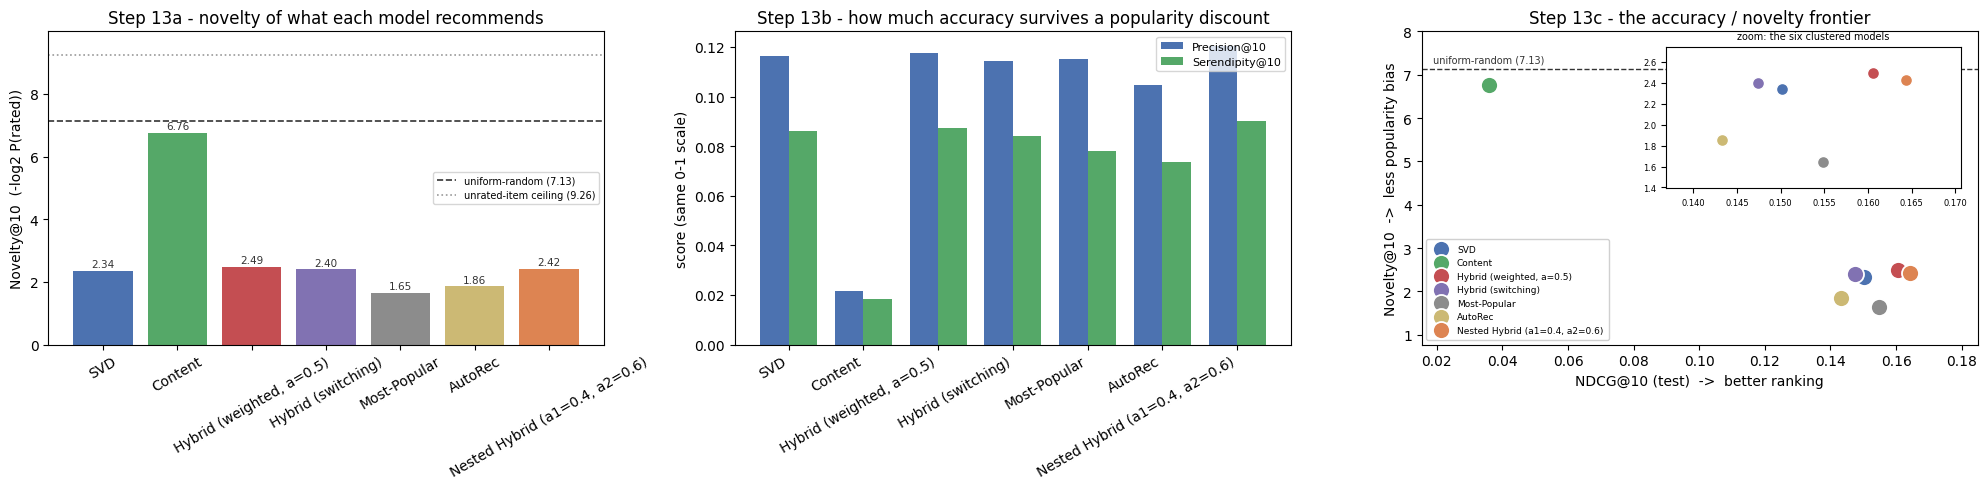

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.0))

# --- 13a: novelty, with both reference lines on the same axis ---------------
nov = combined["Novelty@10"]
axes[0].bar(nov.index, nov.values, color=[palette7.get(n, "#4C72B0") for n in nov.index])
axes[0].axhline(pop_profile.mean_catalogue_novelty, color="#333", linestyle="--", linewidth=1.2,
                label=f"uniform-random ({pop_profile.mean_catalogue_novelty:.2f})")
axes[0].axhline(pop_profile.max_novelty, color="#999", linestyle=":", linewidth=1.2,
                label=f"unrated-item ceiling ({pop_profile.max_novelty:.2f})")
for xi, v in enumerate(nov.values):
    axes[0].text(xi, v + 0.12, f"{v:.2f}", ha="center", fontsize=7.5, color="#333")
axes[0].set_ylim(0, pop_profile.max_novelty * 1.08)
axes[0].set_ylabel("Novelty@10  (-log2 P(rated))")
axes[0].set_title("Step 13a - novelty of what each model recommends")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(fontsize=7)

# --- 13b: serendipity beside precision, same scale on purpose ---------------
x = np.arange(len(combined))
width = 0.38
axes[1].bar(x - width / 2, combined["Precision@10"], width, label="Precision@10", color="#4C72B0")
axes[1].bar(x + width / 2, combined["Serendipity@10"], width, label="Serendipity@10", color="#55A868")
axes[1].set_xticks(x)
axes[1].set_xticklabels(combined.index, rotation=30, ha="right")
axes[1].set_ylabel("score (same 0-1 scale)")
axes[1].set_title("Step 13b - how much accuracy survives a popularity discount")
axes[1].legend(fontsize=8)

# --- 13c: the frontier ------------------------------------------------------
# Names are NOT annotated onto the points. Six of the seven models sit inside
# an NDCG band 0.02 wide, so their text boxes overlap into an unreadable smear
# - the first version of this figure was exactly that. A legend carries
# identity instead, and an inset zooms the cluster so those six are separable
# without putting any text inside the crowded region.
for name in combined.index:
    axes[2].scatter(combined.loc[name, "NDCG@10"], combined.loc[name, "Novelty@10"],
                    s=150, color=palette7.get(name, "#4C72B0"),
                    edgecolor="white", linewidth=1.3, zorder=3, label=name)
axes[2].axhline(pop_profile.mean_catalogue_novelty, color="#333", linestyle="--",
                linewidth=1.0, zorder=1)
axes[2].annotate(f"uniform-random ({pop_profile.mean_catalogue_novelty:.2f})",
                 (0.02, pop_profile.mean_catalogue_novelty),
                 xycoords=("axes fraction", "data"), xytext=(0, 5),
                 textcoords="offset points", fontsize=7, color="#333")
axes[2].set_xlabel("NDCG@10 (test)  ->  better ranking")
axes[2].set_ylabel("Novelty@10  ->  less popularity bias")
axes[2].set_title("Step 13c - the accuracy / novelty frontier")
axes[2].margins(0.16)
# Lower-left is the one empty quadrant here (low ranking AND low novelty), so
# the legend cannot land on a point wherever the numbers move.
axes[2].legend(fontsize=6.5, loc="lower left", framealpha=0.92, borderpad=0.6)

# The six accuracy-oriented models, zoomed. Same colours as the main panel and
# the legend, so no labels are needed inside the inset at all.
cluster = combined.drop(index=["Content"], errors="ignore")
inset = axes[2].inset_axes([0.44, 0.50, 0.53, 0.45])
for name in cluster.index:
    inset.scatter(cluster.loc[name, "NDCG@10"], cluster.loc[name, "Novelty@10"],
                  s=75, color=palette7.get(name, "#4C72B0"),
                  edgecolor="white", linewidth=1.0, zorder=3)
# Without these three lines the main panel's 7.13 guide line draws straight
# THROUGH the inset, where it reads as a stray line belonging to the zoom.
inset.set_zorder(5)
inset.patch.set_facecolor("white")
inset.patch.set_alpha(1.0)
inset.set_title("zoom: the six clustered models", fontsize=7)
inset.tick_params(labelsize=6)
inset.margins(0.3)

plt.tight_layout()
plt.show()